# Модель для пронозирования возраста пользователей на основе их поведения в цифровой среде

### Описание исследования

Заказчик проекта — IT-компания, которая получает доход от контекстной рекламы, то есть от объявлений на страницах своих сайтов. Алгоритмы рекламной сети компании используют демографический таргетинг, включая возрастной. Задача проекта - создать инструмент, который будет автоматически определять возрастную категорию пользователей для показа рекламы на целевую аудиторию.

### Цель исследования

Целью исследования является построение модели многоклассовой классификации, которая предсказывает категорию возраста пользователя на основе его поведения в цифровой среде с метрикой `F1` равной не менее 0.75 на кросс-валидации по обучающей выборке и на тестовой выборке. Результат модели станет основой для показа рекламы на целевую аудиторию определённого возраста и снижения риска показа рекламы для взрослых несовершеннолетним.

### Задачи исследования

В процессе выполнения проекта необходимо реализовать следующие этапы:
- подготовить среду и библиотеки для работы;
- провести исследовательский анализ данных;
- предобработать данные;
- обучить базовые модели и провести для них расчет метрик;
- создать и отобрать признаки;
- подобрать гиперпараметры моделей;
- подготовить артефакты модели для внедрения;
- сделать выводы о результатах работы.

### Постановка задачи машинного обучения

В рамках выполнения проекта необходимо построить модель многоклассовой классификации, которая спрогнозирует возраст пользователя на основе его поведения в цифровой среде.

Таким образом, выполняемая задача - задача многоклассовой классификации. Соответственно, тип задачи - обучение с учителем, так как обучение происходит по размеченным данным.

Целевой переменной является поле `age_category`, которое содержит возрастную категорию пользователя:
- `0` - младше 18;
- `1` - 18-25 лет;
- `2` - 26-40 лет;
- `3` - 41-55 лет;
- `4` - 56+ лет.

Для оценки модели в этом проекте будет использоваться метрика:
- `F1-macro` - сбалансированная между `precision` и `recall` метрика, использует макро-усреднение, чтобы оценивать модель одинаково по всем классам;

Дополнительные метрики:
- `precision_macro` - в скольких случаях в среднем по всем классам предсказания модели оказываются правильными;
- `recall_macro` - в скольких случаях в среднем по всем классам модель умеет находить все объекты, принадлежащие классам.

### Содержимое проекта

1. [Подготовка среды и библиотек.](#1-bullet)<br>
    1.1 [Подготовка библиотек](#1.1-bullet)<br>
    1.2 [Фиксация констант и настройка параметров отображения](#1.2-bullet)<br>
    1.3 [Загрузка данных](#1.3-bullet)<br>
2. [Исследовательский анализ данных.](#2-bullet)<br>
    2.1 [Описание базовой информации о датасетах.](#2.1-bullet)<br>
    2.2 [Анализ целевой переменной.](#2.2-bullet)<br>
    2.3 [Первичная предобработка датафреймов по отдельности.](#2.3-bullet)<br>
    2.4 [Описание базовой информации о новом датасете.](#2.4-bullet)<br>
    2.5 [Анализ признаков.](#2.5-bullet)<br>
    2.6 [Анализ пропущенных значений.](#2.6-bullet)<br>
    2.7 [Анализ категориальных признаков.](#2.7-bullet)<br>
    2.8 [Анализ выбросов и распределений.](#2.8-bullet)<br>
    2.9 [Корреляции.](#2.9-bullet)<br>
3. [Предобработка данных.](#3-bullet)<br> 
    3.1 [Разделение данных на выборки.](#3.1-bullet)<br>
    3.2 [Создание пайплайнов и трансформера.](#3.2-bullet)<br>
4. [Обучение и оценка базовой модели.](#4-bullet)<br>   
5. [Создание и отбор признаков.](#5-bullet)<br>
    5.1 [Фильтрационные методы .](#5.1-bullet)<br>
    5.2 [Методы-обертки.](#5.2-bullet)<br>
    5.3 [Финальный набор признаков.](#5.3-bullet)<br>
6. [Подбор гиперпараметров моделей.](#6-bullet)<br>
    6.1 [Подбор гиперпараметров с помощью GridSearchCV.](#6.1-bullet)<br>
    6.2 [Работа с итоговой моделью.](#6.2-bullet)<br>
7. [Подготовка артефактов модели для внедрения.](#7-bullet)<br>   
8. [Выводы о результатах работы.](#8-bullet)<br>  

<a class="anchor" id="1-bullet"></a>
## 1. Подготовка среды и библиотек

<a class="anchor" id="1.1-bullet"></a>
### 1.1 Подготовка библиотек

Подготовим все необходимые библиотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from phik import phik_matrix
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, SequentialFeatureSelector, RFE
from sklearn.metrics import f1_score, precision_score, recall_score
import joblib

#### Вывод по 1.1: 
Был создан requirements-файл и импортированы все необходимые библиотеки. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="1.2-bullet"></a>
### Фиксация констант и настройка параметров отображения

In [2]:
RANDOM_SEED = 42
TEST_SIZE = 0.2

Установим значение для отображения колонок при работе с датасетом.

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

#### Вывод по 1.2

Были зафиксированы значения констант для дальнейшего использования.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="1.3-bullet"></a>
### 1.3 Загрузка данных

Загрузим все доступные данные.

In [4]:
try: 
    df_users = pd.read_csv('/datasets/ds_s13_users.csv')
    df_visits = pd.read_csv('/datasets/ds_s13_visits.csv')
    df_ads_activity = pd.read_csv('/datasets/ads_activity.csv')
    df_surf_depth = pd.read_csv('/datasets/surf_depth.csv')
    df_primary_device = pd.read_csv('/datasets/primary_device.csv')
    df_cloud_usage = pd.read_csv('/datasets/cloud_usage.csv')
except:
    df_users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
    df_visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
    df_ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
    df_surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
    df_primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
    df_cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

Сохраним данные в отдельные переменные, чтобы в конце проекта проверить корректность загрузки артефактов.

In [5]:
df_users_start = df_users.copy()
df_visits_start = df_visits.copy()
df_ads_activity_start = df_ads_activity.copy()
df_surf_depth_start = df_surf_depth.copy()
df_primary_device_start = df_primary_device.copy()
df_cloud_usage_start = df_cloud_usage.copy()

Соберем датафреймы в один словарь.

In [6]:
dfs = {'df_users': df_users,
       'df_visits': df_visits, 
       'df_ads_activity': df_ads_activity, 
       'df_surf_depth': df_surf_depth, 
       'df_primary_device': df_primary_device, 
       'df_cloud_usage': df_cloud_usage}

In [7]:
for df in dfs:
    print(f'{df}: {dfs[df].shape}')

df_users: (5913, 2)
df_visits: (1065745, 5)
df_ads_activity: (5826, 2)
df_surf_depth: (5715, 2)
df_primary_device: (5669, 2)
df_cloud_usage: (5680, 2)


Из данных видно, что количество строк во всех датафреймах разное, значит необходимо будет проводить слияние датафреймов более аккуратно. Количество столбцов совпадает с заявленным, проверим, совпадают ли названия и типы данных в столбцах с ожидаемымы.

In [8]:
for df in dfs:
    print(f'Датафрейм {df}')
    display(dfs[df].head(3))
    print(f'\nТипы данных:\n{dfs[df].dtypes}\n'+ '-' * 60)

Датафрейм df_users


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0



Типы данных:
user_id           str
age_category    int64
dtype: object
------------------------------------------------------------
Датафрейм df_visits


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18



Типы данных:
date                str
daytime             str
session_id          str
user_id             str
website_category    str
dtype: object
------------------------------------------------------------
Датафрейм df_ads_activity


...


Типы данных:
user_id       str
surf_depth    str
dtype: object
------------------------------------------------------------
Датафрейм df_primary_device


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук



Типы данных:
user_id           str
primary_device    str
dtype: object
------------------------------------------------------------
Датафрейм df_cloud_usage


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True



Типы данных:
user_id         str
cloud_usage    bool
dtype: object
------------------------------------------------------------


Анализ выгруженных признаков не выявил ошибок в названии признаков. Типы данных по большей части корректные, за исключением нескольких моментов:
- признак `age_category` датафрейма `df_users` может принимать только значения 0-4, но имеет тип данных int64. Размерность которого может быть сокращена;
- признак `date` датафрейма `df_visits` имеет тип данных object, хотя должен быть `datetime`;
- возможно, из признака `website_category` датафрейма `df_visits` может быть убрано слово `Category` в каждой строке и тип данных изменен на целочисленный вместо `object`.

#### Вывод по 1.3 
Данные датасетов были выгружены успешно. Количество столбцов и их названия совпали с ожидаемыми, типы данных у большинства столбцов корректные и не требуют изменений. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Вывод по разделу 1
Была проведена настройка библиотек, зафиксированы константы, выгружены необходимые для дальнейшей работы данные, проведен анализ корректности выгрузки данных, в ходе которого выяснилось, что:
- размерность типа данных признака `age_category` датафрейма `users` может быть сокращена;
- признак `date` датафрейма `df_visits` имеет тип данных object, хотя должен быть `datetime`;
- при удалении слова `Category` их каждой строки датафрейма `df_visits` признака `website_category`, тип данных признака может быть изменен на целочисленный

<a class="anchor" id="2-bullet"></a>
## 2. Исследовательский анализ данных

<a class="anchor" id="2.1-bullet"></a>
### 2.1 Описание базовой информации о датасетах 

В проекте предстоит классифицировать пользователей по 5 возрастным группам, целевая переменная находится в датафрейме `users`. В данном датафрейме каждому пользователю сопоставляется своя возрастная категория.

При предсказании возрастной категории важно учитывать различные аспекты интернет-жизни пользователя. Так:
- датафрейм `visits` содержит в себе логи посещения сайтов пользователями, отсюда важными признаками могут оказаться время посещения сайта, например, можно предположить, что подростки более активны ночью в интернете, чем взрослые, а также категории сайтов;
- датафрейм `ads_activity` для каждого пользователя содержит данные о том, как часто пользователь взаимодействует с рекламой;
- из `surf_depth` можно узнать о том, насколько глубоко пользователь переходит по сайтам во время одной сессии;
- `primary_device` свидетельствует о типе основного устройства пользователя для выхода в Интернет;
- `cloud_usage` несет информацию о том, обращается ли пользователь к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

Как видно из пункта 1.3 датафреймы содержат в основном категориальные данные, количество записей в каждом датасете разное. Размеры датасетов распределились так:
- df_users: (5913, 2);
- df_visits: (1065745, 5);
- df_ads_activity: (5826, 2);
- df_surf_depth: (5715, 2);
- df_primary_device: (5669, 2);
- df_cloud_usage: (5680, 2).

Подобных результатов стоило ожидать: во всех датафреймах кроме `df_visits` примерно около 5700-5900 записей, информация агргегирована для каждого пользователя отдельно. В `df_visits` же собраны логи - посещения сайтов пользователями, поэтому записей в данном датафрейме намного больше - более миллиона.

#### Вывод по 2.1 
Была охарактеризована общая информация о всех имеющихся датафреймах.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.2-bullet"></a>
### 2.2 Анализ целевой переменной 

Целевой переменной является признак `age_category` датафрейма `users`, содержащая следующие категории:
- `0` - младше 18;
- `1` - 18-25 лет;
- `2` - 26-40 лет;
- `3` - 41-55 лет;
- `4` - 56+ лет.

Проверим количество объектов в каждом из классов. Перед этим посмотрим, уникально ли количество пользователей в датафрейме, чтобы не учитывать некорректные данные.

In [9]:
print(f'''Количество строк датафрейма: {df_users.shape[0]}
Количество уникальных пользователей: {df_users["user_id"].nunique()}''')

Количество строк датафрейма: 5913
Количество уникальных пользователей: 5826


Количества не совпали. Проверим, возможно, причиной этому послужило наличие дубликатов в данных.

In [10]:
print(f'''Количество дубликатов: {df_users.duplicated().sum()}
Разница между кол-вом строк датафреймов и кол-вом уникальных польователей: {df_users.shape[0] - df_users["user_id"].nunique()}''')

Количество дубликатов: 87
Разница между кол-вом строк датафреймов и кол-вом уникальных польователей: 87


Количества совпали. Тогда сразу удалим из датафрейма полные дубликаты, чтобы корректно провести дальнейший анализ.

In [11]:
df_users = df_users.drop_duplicates()

Посмотрим на результат после очистки от дубликатов.

In [12]:
print(f'''Количество строк датафрейма: {df_users.shape[0]}
Количество уникальных пользователей: {df_users["user_id"].nunique()}''')

Количество строк датафрейма: 5826
Количество уникальных пользователей: 5826


Теперь можно исследовать распределение целевой переменной.

In [13]:
age_category_dist = pd.DataFrame({'Абсолютные значения': df_users['age_category'].value_counts(),
                                 'Относительные значения (%)': round(df_users['age_category'].value_counts(normalize=True) * 100, 2)})
age_category_dist

,Абсолютные значения,Относительные значения (%)
age_category,,
4,1766,30.31
2,1439,24.70
3,1254,21.52
0,853,14.64
1,514,8.82


Судя по распределению целевой переменной, наблюдается дисбаланс классов - представителей категории `1` - 18-25 лет примерно в 3 раза меньше, чем представителей категории `4` - 56+ лет.

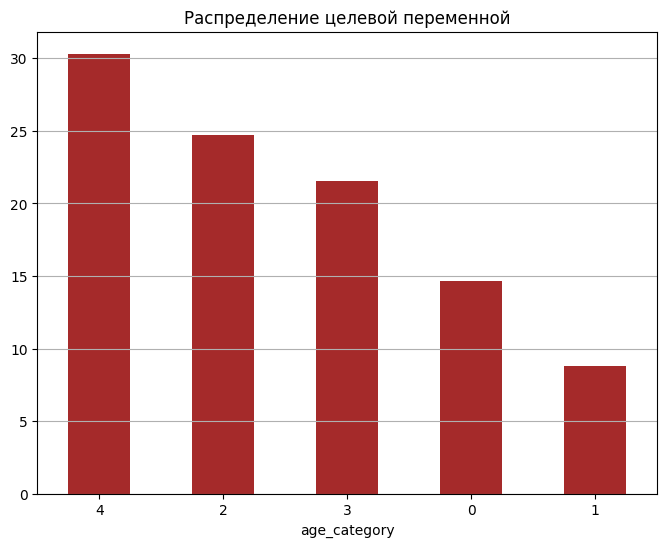

In [14]:
age_category_dist['Относительные значения (%)'].plot(kind='bar',
                                                     title='Распределение целевой переменной',
                                                     figsize=(8, 6),
                                                     rot=0,
                                                     color='brown').grid(axis='y')

Судя по графику, наиболее распространенной возрастной категорией IT-компании являются взрослые люди в возрасте 56+ лет, далее группы распределились так: 41-55 лет, 26-40 лет, младше 18, наименее распространенной категорией являются пользователи в возрасте 18-25 лет. 

Дисбаланс между классами не такой явный, хоть он и присутствует. Кроме того, для нас важно, чтобы:
- для каждого класса тех объектов, что были предсказаны моделью как принадлежащие к этому классу, действительно к нему принадлежали; 
- чтобы для каждого класса было предсказано как можно больше в целом действительно принадлежаших классу объектов. 

Таким образом, обе метрики, и precision, и recall важны, так как необходимо предсказывать классы как можно точнее и не присваивать классам не их объекты. В связи с этим в качестве основной метрики возьмем F1, котора учитывает одновременно и precision, и recall. А их по /отдельности будем учитывать в качестве дополнительных метрик.

#### Вывод по 2.2
Было изучено распределение целевой переменной, выявлено, что наиболее распространенной возрастной категорией IT-компании являются взрослые люди в возрасте 56+ лет, наименее распространенной категорией - пользователи в возрасте 18-25 лет.

Так как важно правильно распределять объекты по классам и не присваивать классам не принадлежащие им объекты, в качестве основной метрики была выбрана `F1-мера`, дополнительные метрики - `precision` и `recall`. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.3-bullet"></a>
### 2.3 Первичная предобработка датафреймов по отдельности

Перед проведением предобработки общего датафрейма, исследуем датафреймы по отдельности и напишем функцию для их соединения.

Напишем функцию для быстрой предобработки "простых" датафреймов - у которых всего 1 столбец, не считая `user_id`.

In [15]:
def preprocess_df(df_for_process, name_col):
    print('Проверим кол-во дубликатов и удалим их при необходимости:')
    print(f'Кол-во дубликатов: {df_for_process.duplicated().sum()}')
    if df_for_process.duplicated().sum() > 0:
        df_for_process = df_for_process.drop_duplicates()
        print(f'Кол-во дубликатов после их удаления: {df_for_process.duplicated().sum()}\n')
        
    print('Проверим количество пропусков в данных:')
    print(df_for_process.isna().sum(), '\n')
    
    print('Проверка на уникальность каждого идентификатора пользователя. Результат:')
    print(df_for_process['user_id'].nunique() == df_for_process.shape[0], '\n')

    print(f'Проверка столбца {name_col} на выбросы. Уникальные значения:')
    print(df_for_process[name_col].unique())
    return df_for_process

**Датафрейм df_users**

In [16]:
df_users = preprocess_df(df_users, 'age_category')

Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 0
Проверим количество пропусков в данных:
user_id         0
age_category    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца age_category на выбросы. Уникальные значения:
[4 2 0 1 3]


Пропусков в данных нет. Распределение целевой переменной мы так же проверяли в пункте 2.2, выбросов найдено не было.

**Результат по датафрейму**: дубликаты были удалены в пункте 2.2, выбросов  пропусков найдено не было.

**Датафрейм df_visits**

Проверим на наличие явных дубликатов.

In [17]:
df_visits.duplicated().sum()

15750

Удалим явные дубликаты.

In [18]:
df_visits = df_visits.drop_duplicates()
print(f'Результат удаления (кол-во дубликатов): {df_visits.duplicated().sum()}')

Результат удаления (кол-во дубликатов): 0


Проверим на наличие пропусков.

In [19]:
df_visits.isna().sum()

date                0
daytime             0
session_id          0
user_id             0
website_category    0
dtype: int64

Пропуски найдены не были.

Проанализируем столбцы:
- дата посещения сайта `date` вряд ли оказывает влияние на возрастную категорию пользователя, ее мы не будем анализировать подробно;
- анонимизированное время посещения сайта `daytime` может влиять на результат - например, подростки могут сидеть в интернете ночью чаще, чем взрослые люди;
- уникальный идентификатор сессии `session_id` - идентификационный признак, однако из него можно получить информацию о количестве сессий пользователя в день;
- `website_category` - анонимизированная категория сайта для сегментации аудитории. Важный признак, категории посещаемых сайтов могут оказать значительное влияние на предсказание - например, подростки могут интересоваться современными играми, модными течениями, что, скорее всего, не привлечет взрослых людей.

Сначала проведем работу со временем посещения сайта `daytime`. Для каждого пользователя выявим наиболее активное время суток и долю интернет-активноси, приходящуюся на разное время суток.

In [20]:
def get_most_frequent(series):
    counts = series.value_counts(normalize=True) 
    return counts.index[0], counts['утро'], counts['день'], counts['вечер'], counts.get('ночь', 0)
    
daytime_processing = df_visits.groupby(by='user_id')['daytime'].apply(get_most_frequent)

In [21]:
daytime_processed = pd.DataFrame(daytime_processing.tolist(),
                                 index=daytime_processing.index,
                                 columns=['most_popular_daytime', 'count_morning', 'count_day', 'count_evening', 'count_night'])
daytime_processed = daytime_processed.reset_index()
daytime_processed.head(3)

,user_id,most_popular_daytime,count_morning,count_day,count_evening,count_night
0,0010-5cf8f6b38a7b6c70a021-009dbcda,вечер,0.164835,0.326007,0.413919,0.095238
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,день,0.264865,0.372973,0.275676,0.086486
2,0014-d3032d60979a8d2b3077-f09bdce8,день,0.213675,0.384615,0.307692,0.094017


Мы получили такую сводную информацию для каждого пользователя:
- наиболее активное время суток у пользователя;
- долю интернет-активности для каждого времени суток.

Проведем работу с категориями сайтов. Создадим для каждой категории сайта свой признак и посчитаем долю интернет-активности для каждого пользователя, приходящуюся на этот сайт.

In [22]:
def processing_website(series):
    counts = series.value_counts(normalize=True) 
    res = []
    
    for i in range(1, 21):
        res.append(counts.get(f'Category {i:02d}', 0))

    return res
    
website_category_processing = df_visits.groupby(by='user_id')['website_category'].apply(processing_website)

In [23]:
columns_category = [f'website_category_{i}' for i in range(1, 21)] 

In [24]:
website_category_processed = pd.DataFrame(website_category_processing.tolist(),
                                          index=website_category_processing.index,
                                         columns=columns_category)
website_category_processed = website_category_processed.reset_index()

In [25]:
website_category_processed.head(3)

,user_id,website_category_1,website_category_2,website_category_3,website_category_4,website_category_5,website_category_6,website_category_7,website_category_8,website_category_9,website_category_10,website_category_11,website_category_12,website_category_13,website_category_14,website_category_15,website_category_16,website_category_17,website_category_18,website_category_19,website_category_20
0,0010-5cf8f6b38a7b6c70a021-009dbcda,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622
2,0014-d3032d60979a8d2b3077-f09bdce8,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188


Мы получили для каждого пользователя долевое распределение интересов по разным категориям сайтов.

Получим среднее количество сессий пользователей в день.

In [26]:
mean_count_sessions = pd.DataFrame(df_visits.groupby(by=['user_id', 'date'])['session_id'].count()
                                   .groupby(by='user_id').mean())
mean_count_sessions = mean_count_sessions.reset_index()
mean_count_sessions = mean_count_sessions.rename(columns={'session_id': 'mean_sessions_count'})
mean_count_sessions.head(3)

,user_id,mean_sessions_count
0,0010-5cf8f6b38a7b6c70a021-009dbcda,39.000000
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,13.214286
2,0014-d3032d60979a8d2b3077-f09bdce8,8.357143


В целом, из данного датафрейма больше нельзя получить важной информации. Соединим получившиеся датафреймы и будем их использовать далее для построения единого датафрейма.

In [27]:
print(f'''Размеры датафреймов до содинения:
daytime_processed: {daytime_processed.shape}
website_category_processed: {website_category_processed.shape}
mean_count_sessions: {mean_count_sessions.shape}''')

Размеры датафреймов до содинения:
daytime_processed: (5826, 6)
website_category_processed: (5826, 21)
mean_count_sessions: (5826, 2)


In [28]:
df_visits_new = mean_count_sessions.merge(website_category_processed, on='user_id')
df_visits_new = df_visits_new.merge(daytime_processed, on='user_id')
df_visits_new.head(3)

,user_id,mean_sessions_count,website_category_1,website_category_2,website_category_3,website_category_4,website_category_5,website_category_6,website_category_7,website_category_8,website_category_9,website_category_10,website_category_11,website_category_12,website_category_13,website_category_14,website_category_15,website_category_16,website_category_17,website_category_18,website_category_19,website_category_20,most_popular_daytime,count_morning,count_day,count_evening,count_night
0,0010-5cf8f6b38a7b6c70a021-009dbcda,39.000000,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.091575,вечер,0.164835,0.326007,0.413919,0.095238
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,13.214286,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.021622,день,0.264865,0.372973,0.275676,0.086486
2,0014-d3032d60979a8d2b3077-f09bdce8,8.357143,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.034188,день,0.213675,0.384615,0.307692,0.094017


In [29]:
print(f'Размер датафрейма после соединения: {df_visits_new.shape}')

Размер датафрейма после соединения: (5826, 27)


Количество строк датафрейма после соединения осталось корректным, выбросов найдено не было, иначе бы функции не сработали.

**Результат по датафрейму**: на основе датафрейма df_visits были составлены новые признаки с наиболее активным временем суток у пользователей, долей интернет-активности для каждого времени суток, долевым распределением интересов пользователей по разным категориям сайтов, средним количеством сессий пользователей в день.

**Датафрейм df_ads_activity**

Проведем работу с датафреймом.

In [30]:
df_ads_activity = preprocess_df(df_ads_activity, 'ads_activity')

Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 233
Кол-во дубликатов после их удаления: 0

Проверим количество пропусков в данных:
user_id         0
ads_activity    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца ads_activity на выбросы. Уникальные значения:
<StringArray>
['очень часто', 'редко', 'очень редко', 'умеренно', 'часто']
Length: 5, dtype: str


**Результат по датафрейму**: были удалены дубликаты, выбросы и пропуски найдены не были.

**Датафрейм df_surf_depth**

Проведем работу с датафреймом.

In [31]:
df_surf_depth = preprocess_df(df_surf_depth, 'surf_depth')

Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 0
Проверим количество пропусков в данных:
user_id       0
surf_depth    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца surf_depth на выбросы. Уникальные значения:
<StringArray>
['поверхностно', 'глубоко', 'средне']
Length: 3, dtype: str


**Результат по датафрейму**: дубликаты, выбросы и пропуски найдены не были.

**Датафрейм df_primary_device**

Проведем работу с датафреймом.

In [32]:
df_primary_device = preprocess_df(df_primary_device, 'primary_device')

Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 0
Проверим количество пропусков в данных:
user_id           0
primary_device    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца primary_device на выбросы. Уникальные значения:
<StringArray>
['смартфон', 'ПК', 'ноутбук', 'планшет']
Length: 4, dtype: str


**Результат по датафрейму**: дубликаты, выбросы и пропуски найдены не были.

**Датафрейм df_cloud_usage**

Проведем работу с датафреймом.

In [33]:
df_cloud_usage = preprocess_df(df_cloud_usage, 'cloud_usage')

Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 0
Проверим количество пропусков в данных:
user_id        0
cloud_usage    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца cloud_usage на выбросы. Уникальные значения:
[False  True]


**Результат по датафрейму**: дубликаты, выбросы и пропуски найдены не были.

Проверим размерности датасетов.

In [34]:
dfs = {'df_users': df_users,
       'df_visits_new': df_visits_new, 
       'df_ads_activity': df_ads_activity, 
       'df_surf_depth': df_surf_depth, 
       'df_primary_device': df_primary_device, 
       'df_cloud_usage': df_cloud_usage}

In [35]:
for df in dfs:
    print(f'{df}: {dfs[df].shape}')

df_users: (5826, 2)
df_visits_new: (5826, 27)
df_ads_activity: (5593, 2)
df_surf_depth: (5715, 2)
df_primary_device: (5669, 2)
df_cloud_usage: (5680, 2)


Для всех датасетов при соединении будем использовать left join, где левой таблицей будет `df_users`, чтобы не потерять информацию о целевых классах. 

Напишем отдельную функцию для объединения представленной в датасете информации в датафрейм.

In [36]:
def create_new_df(df_users,
                 df_visits,
                 df_ads_activity,
                 df_surf_depth,
                 df_primary_device,
                 df_cloud_usage):
    
    
    df = df_users.merge(df_visits_new, on='user_id', how='left')
    print(f'Размер после соединения df_users и df_visits_new:\n{df.shape}')
    
    df = df.merge(df_ads_activity, on='user_id', how='left')
    print(f'Размер после соединения df и df_ads_activity:\n{df.shape}')
    
    df = df.merge(df_surf_depth, on='user_id', how='left')
    print(f'Размер после соединения df и df_surf_depth:\n{df.shape}')
    
    df = df.merge(df_primary_device, on='user_id', how='left')
    print(f'Размер после соединения df и df_primary_device:\n{df.shape}')
    
    df = df.merge(df_cloud_usage, on='user_id', how='left')
    print(f'Размер после соединения df и df_cloud_usage:\n{df.shape}')
    
    return df

Создадим функцию, которая будет включать в себя все этапы, проделанные выше с объяснениями, по отдельности.

In [37]:
def processing_initial_tables(df_users,
                              df_visits,
                              df_ads_activity,
                              df_surf_depth,
                              df_primary_device,
                              df_cloud_usage):
    # блок работы с датафреймами из 2 признаков
    print(f'---> Обработка таблицы df_users')
    df_users = preprocess_df(df_users, 'age_category')
    
    print(f'\n---> Обработка таблицы df_ads_activity')
    df_ads_activity = preprocess_df(df_ads_activity, 'ads_activity')
    
    print(f'\n---> Обработка таблицы df_surf_depth')
    df_surf_depth = preprocess_df(df_surf_depth, 'surf_depth')
    
    print(f'\n---> Обработка таблицы df_primary_device')
    df_primary_device = preprocess_df(df_primary_device, 'primary_device')
    
    print(f'\n---> Обработка таблицы df_cloud_usage')
    df_cloud_usage = preprocess_df(df_cloud_usage, 'cloud_usage')
    
    # блок работы с df_visits
    print('\n---> Обработка таблицы df_visits')
    df_visits = df_visits.drop_duplicates()
    
    # наиболее активное время суток и доля интернет-активноси, приходящаяся на разное время суток.
    daytime_processing = df_visits.groupby(by='user_id')['daytime'].apply(get_most_frequent)
    daytime_processed = pd.DataFrame(daytime_processing.tolist(),
                                     index=daytime_processing.index,
                                     columns=['most_popular_daytime', 'count_morning', 'count_day', 'count_evening', 'count_night'])
    daytime_processed = daytime_processed.reset_index()

    # признаки с категориями сайтов
    website_category_processing = df_visits.groupby(by='user_id')['website_category'].apply(processing_website)
    columns_category = [f'website_category_{i}' for i in range(1, 21)] 
    website_category_processed = pd.DataFrame(website_category_processing.tolist(),
                                              index=website_category_processing.index,
                                             columns=columns_category)
    website_category_processed = website_category_processed.reset_index()

    # среднее количество сессий в день
    mean_count_sessions = pd.DataFrame(df_visits.groupby(by=['user_id', 'date'])['session_id'].count()
                                       .groupby(by='user_id').mean())
    mean_count_sessions = mean_count_sessions.reset_index()
    mean_count_sessions = mean_count_sessions.rename(columns={'session_id': 'mean_sessions_count'})
    
    # объединение созданных выше таблиц для df_visits
    df_visits_new = mean_count_sessions.merge(website_category_processed, on='user_id')
    df_visits_new = df_visits_new.merge(daytime_processed, on='user_id')

    # создание итогового датафрейма
    df = create_new_df(df_users,
                       df_visits,
                       df_ads_activity,
                       df_surf_depth,
                       df_primary_device,
                       df_cloud_usage)
    
    return df

In [38]:
df = create_new_df(df_users,
                 df_visits_new,
                 df_ads_activity,
                 df_surf_depth,
                 df_primary_device,
                 df_cloud_usage)

Размер после соединения df_users и df_visits_new:
(5826, 28)
Размер после соединения df и df_ads_activity:
(5826, 29)
Размер после соединения df и df_surf_depth:
(5826, 30)
Размер после соединения df и df_primary_device:
(5826, 31)
Размер после соединения df и df_cloud_usage:
(5826, 32)


В результате соединений мы получили общий датафрейм размерностью 5826 строк и 31 признак (+ целевая переменная), не потеряв информации ни по одному из классов.

#### Вывод по 2.3
Была проведена первичная предобработка по отдельности: на основе датафрейма `df_visits` были составлены новые признаки с наиболее активным временем суток у пользователей, долей интернет-активности для каждого времени суток, долевым распределением интересов пользователей по разным категориям сайтов, средним количеством сессий пользователей в день; в некоторых признаках были найдены дубликаты, которые были удалены. Выбросов и пропусков найдена в данных не было.

Была создана функция для соединения всех данных в единый датафрейм, воспользовавшись которой мы получили все данные, сведенные воедино, без потери информации о целевых классах.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.4-bullet"></a>
### 2.4 Описание базовой информации о новом датасете

Опишем основную информацию о созданном датафрейме `df`.

In [39]:
df.shape

(5826, 32)

Датафрейм содержит 5826 объектов и 32 признака, один из которых - целевой признак.

In [40]:
df.dtypes

user_id                     str
age_category              int64
mean_sessions_count     float64
website_category_1      float64
website_category_2      float64
website_category_3      float64
website_category_4      float64
website_category_5      float64
website_category_6      float64
website_category_7      float64
website_category_8      float64
website_category_9      float64
website_category_10     float64
website_category_11     float64
website_category_12     float64
website_category_13     float64
website_category_14     float64
website_category_15     float64
website_category_16     float64
website_category_17     float64
website_category_18     float64
website_category_19     float64
website_category_20     float64
most_popular_daytime        str
count_morning           float64
count_day               float64
count_evening           float64
count_night             float64
ads_activity                str
surf_depth                  str
primary_device              str
cloud_us

Изначальные признаки датасета в основном имеют категориальный тип данных, сгенерированные нами - вещественный, за исключением `most_popular_daytime`, который тоже категориальный.

Можно заметить, что признаку `cloud_usage`, который изначально являлся бинарным, из-за появления пропусков при присоединении датафреймов был присвоен тип данных `object`. Сразу обработаем этот признак, приведем True/False к 0/1.

In [41]:
ordinal_encoder = OrdinalEncoder()
df['cloud_usage'] = ordinal_encoder.fit_transform(df[['cloud_usage']])

Тип признака изменился на `float64`.

In [42]:
df.dtypes

user_id                     str
age_category              int64
mean_sessions_count     float64
website_category_1      float64
website_category_2      float64
website_category_3      float64
website_category_4      float64
website_category_5      float64
website_category_6      float64
website_category_7      float64
website_category_8      float64
website_category_9      float64
website_category_10     float64
website_category_11     float64
website_category_12     float64
website_category_13     float64
website_category_14     float64
website_category_15     float64
website_category_16     float64
website_category_17     float64
website_category_18     float64
website_category_19     float64
website_category_20     float64
most_popular_daytime        str
count_morning           float64
count_day               float64
count_evening           float64
count_night             float64
ads_activity                str
surf_depth                  str
primary_device              str
cloud_us

Для каждого пользователя известно:
- среднее количество сессий в день `mean_sessions_count`;
- долевое распределение посещений по категориям сайтов;
- наиболее популярное для пользователя время дня для активности в интернете `most_popular_daytime`;
- долевой распределение активности пользователя по времени суток - `count_morning`, `count_day`, `count_evening`, `count_night`;
- характеристика CTR `ads_activity`;
- глубина перехода пользователя по сайтам во время одной сессии `surf_depth`;
- информация о типе основного устройства пользователя `primary_device`;
- обращается ли пользователь к облачным ресурсам `cloud_usage`.

Распределение целевой переменной не менялось, поэтому нет смысла в его повторном рассмотрении.

#### Вывод по 2.4
Была рассмотрена основная информация о датасете и типах данных его признаков.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.5-bullet"></a>
### 2.5 Анализ признаков

Все признаки датасета являются важными для обучения одели, за исключением `user_id` - идентификационного признака, сразу удалим его.

In [43]:
df = df.drop('user_id', axis=1)

Проверим более подробно корректность присваивания типов данных признакам. Изначально присвоенные типы данных для признаков:

In [44]:
num_cols = list(df.select_dtypes(include=['int64', 'float64']).columns)
num_cols.remove('age_category')

cat_cols = list(df.select_dtypes(include='str').columns)

print(f'''Числовые признаки ({len(num_cols)}):
{num_cols}
{'-' * 50}
Категориальные признаки ({len(cat_cols)}):
{cat_cols}''')

Числовые признаки (26):
['mean_sessions_count', 'website_category_1', 'website_category_2', 'website_category_3', 'website_category_4', 'website_category_5', 'website_category_6', 'website_category_7', 'website_category_8', 'website_category_9', 'website_category_10', 'website_category_11', 'website_category_12', 'website_category_13', 'website_category_14', 'website_category_15', 'website_category_16', 'website_category_17', 'website_category_18', 'website_category_19', 'website_category_20', 'count_morning', 'count_day', 'count_evening', 'count_night', 'cloud_usage']
--------------------------------------------------
Категориальные признаки (4):
['most_popular_daytime', 'ads_activity', 'surf_depth', 'primary_device']


Типы данных были корректно назначены признакам, все числовые признаки являются непрерывными, кроме `cloud_usage`, который является дискретным.

#### Вывод по 2.5
Типы данных признакам были назначены корректно при загрузке датафрейма и работы над ним, все числовые признаки яявляются непрерывными. Был удален один явно ненужный, идентификационный признак, `user_id`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.6-bullet"></a>
### 2.6 Анализ пропущенных значений

Проверим количество пропущенных значений в абсолютных и относительных количествах. 

In [45]:
pd.DataFrame({'Абсолютные зн-ия': df.isna().sum(), 
              'Относительные значения': df.isna().sum() / df.shape[0]})

,Абсолютные зн-ия,Относительные значения
age_category,0,0.000000
mean_sessions_count,0,0.000000
website_category_1,0,0.000000
website_category_2,0,0.000000
website_category_3,0,0.000000
website_category_4,0,0.000000
website_category_5,0,0.000000
website_category_6,0,0.000000
website_category_7,0,0.000000
website_category_8,0,0.000000


Проверим, встречаются ли эти пропуски в одних и тех же строках.

In [46]:
print(f'Пропуски в ads_activity и surf_depth: {df[df["ads_activity"].isna()]["surf_depth"].isna().sum()}')
print(f'Пропуски в ads_activity и primary_device: {df[df["ads_activity"].isna()]["primary_device"].isna().sum()}')
print(f'Пропуски в ads_activity и cloud_usage: {df[df["ads_activity"].isna()]["cloud_usage"].isna().sum()}\n')
print(f'Пропуски в surf_depth и primary_device: {df[df["surf_depth"].isna()]["primary_device"].isna().sum()}')
print(f'Пропуски в surf_depth и cloud_usage: {df[df["surf_depth"].isna()]["cloud_usage"].isna().sum()}\n')
print(f'Пропуски в primary_device и cloud_usage: {df[df["primary_device"].isna()]["cloud_usage"].isna().sum()}')

Пропуски в ads_activity и surf_depth: 4
Пропуски в ads_activity и primary_device: 4
Пропуски в ads_activity и cloud_usage: 8

Пропуски в surf_depth и primary_device: 3
Пропуски в surf_depth и cloud_usage: 2

Пропуски в primary_device и cloud_usage: 7


Были найдены строки, где пропуски встречаются сразу в паре позиций, но их количество мало, чтобы говорить о какой-либо тенденции в данных.

Если мы удалим все строки с пропусками, то рискуем потерять важную информацию. Все признаки, кроме `cloud_usage` с пропусками являются категориальными, поэтому в них нельзя заменить пропуски, например, медианой. Тогда заменим все пропуски в данных новой категорией "Неизвестно". В признаке `cloud_usage` заполним пропуски модой.

#### Вывод по 2.6
Были найдены и проанализированы пропуски в признаках `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`. Принято решение заменить их на моду у `cloud_usage` и категорию "Неизвестно" у остальных признаков.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.7-bullet"></a>
### 2.7 Анализ категориальных признаков

Категориальные признаки были выделены ранее. Рассмотрим их.

In [47]:
cat_cols

['most_popular_daytime', 'ads_activity', 'surf_depth', 'primary_device']

In [48]:
for col in cat_cols:
    print(f'Признак: {col}')
    print(f'Количество уникальных значений: {df[col].nunique()}\n')

Признак: most_popular_daytime
Количество уникальных значений: 3

Признак: ads_activity
Количество уникальных значений: 5

Признак: surf_depth
Количество уникальных значений: 3

Признак: primary_device
Количество уникальных значений: 4



Количество уникальных значений во всех категориальных признаках достатоно небольшое, однако если мы все эти признаки закодируем с помощью One-Hot Encoding, получится 3 + 5 + 3 + 4 = 15 новых столбцов, что довольно много. 

Тогда закодируем с помощью One-Hot признаки `most_popular_daytime` (3 уникальных значения), `surf_depth` (3 уникальных значения), а остальные с помощью Target Encoding.

In [49]:
cat_cols_target = cat_cols.copy()
cat_cols_onehot = ['most_popular_daytime', 'surf_depth']
for el in cat_cols_onehot:
    cat_cols_target.remove(el)
print(f'''One-Hot Encoding: {cat_cols_onehot}
Target Encoding: {cat_cols_target}''')

One-Hot Encoding: ['most_popular_daytime', 'surf_depth']
Target Encoding: ['ads_activity', 'primary_device']


#### Вывод по 2.7
Было проанализировано количество уникальных знаений в категориальных признаках и определена стратегия работы с их кодированием. Было решено использовать:
- One-Hot Encoding для `most_popular_daytime`, `surf_depth`;
- Target Encoding для оставшихся признаков. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.8-bullet"></a>
### 2.8 Анализ выбросов и распределений

Проанализируем данные на предмет выбросов с помощью статистической информации и графиков.

In [50]:
df.describe()

,age_category,mean_sessions_count,website_category_1,website_category_2,website_category_3,website_category_4,website_category_5,website_category_6,website_category_7,website_category_8,website_category_9,website_category_10,website_category_11,website_category_12,website_category_13,website_category_14,website_category_15,website_category_16,website_category_17,website_category_18,website_category_19,website_category_20,count_morning,count_day,count_evening,count_night,cloud_usage
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5680.000000
mean,2.440439,12.874047,0.049933,0.041647,0.065480,0.048701,0.057005,0.053715,0.051322,0.052678,0.050884,0.049334,0.036852,0.047742,0.064447,0.043433,0.048679,0.043211,0.046991,0.048007,0.051999,0.047940,0.198733,0.364961,0.358199,0.078108,0.519542
std,1.381287,5.369733,0.031238,0.029358,0.051979,0.027860,0.029300,0.028035,0.029239,0.032203,0.028265,0.028688,0.027020,0.030454,0.057089,0.029823,0.028532,0.028434,0.029080,0.031702,0.028733,0.029135,0.038134,0.045206,0.048836,0.024633,0.499662
min,0.000000,7.142857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.049505,0.217822,0.214286,0.000000,0.000000
25%,2.000000,8.857143,0.026786,0.018779,0.020000,0.029304,0.036776,0.033898,0.030000,0.029126,0.030422,0.029412,0.016048,0.024845,0.008130,0.020000,0.028846,0.021277,0.025641,0.024540,0.031059,0.026667,0.172575,0.335058,0.324324,0.060606,0.000000
50%,3.000000,11.928571,0.048630,0.039697,0.060241,0.046296,0.055215,0.051282,0.050000,0.050533,0.049417,0.047619,0.033528,0.046403,0.056936,0.041237,0.047619,0.040381,0.045161,0.044329,0.050000,0.045595,0.196765,0.365385,0.357542,0.076142,1.000000
75%,4.000000,15.214286,0.070000,0.060606,0.101695,0.066169,0.075885,0.070866,0.070000,0.074286,0.068801,0.066865,0.054217,0.068182,0.102795,0.062850,0.067227,0.060309,0.064852,0.067797,0.070000,0.066667,0.223863,0.395664,0.391304,0.093407,1.000000
max,4.000000,59.928571,0.182927,0.180556,0.261438,0.188119,0.172131,0.171053,0.165414,0.188679,0.188034,0.217822,0.174603,0.178571,0.295918,0.190000,0.198020,0.160305,0.187970,0.195804,0.180000,0.179688,0.360000,0.532710,0.530000,0.198020,1.000000


Сводная статистическая информация выглядит корректно.

Построим гистограммы и диаграммы размаха для непрерывных числовых признаков (все числовые, кроме `cloud_usage`).

In [51]:
print(f'''Количество числовых признаков: {len(num_cols)}
Количество категориальных признаков: {len(cat_cols)}
''')

Количество числовых признаков: 26
Количество категориальных признаков: 4



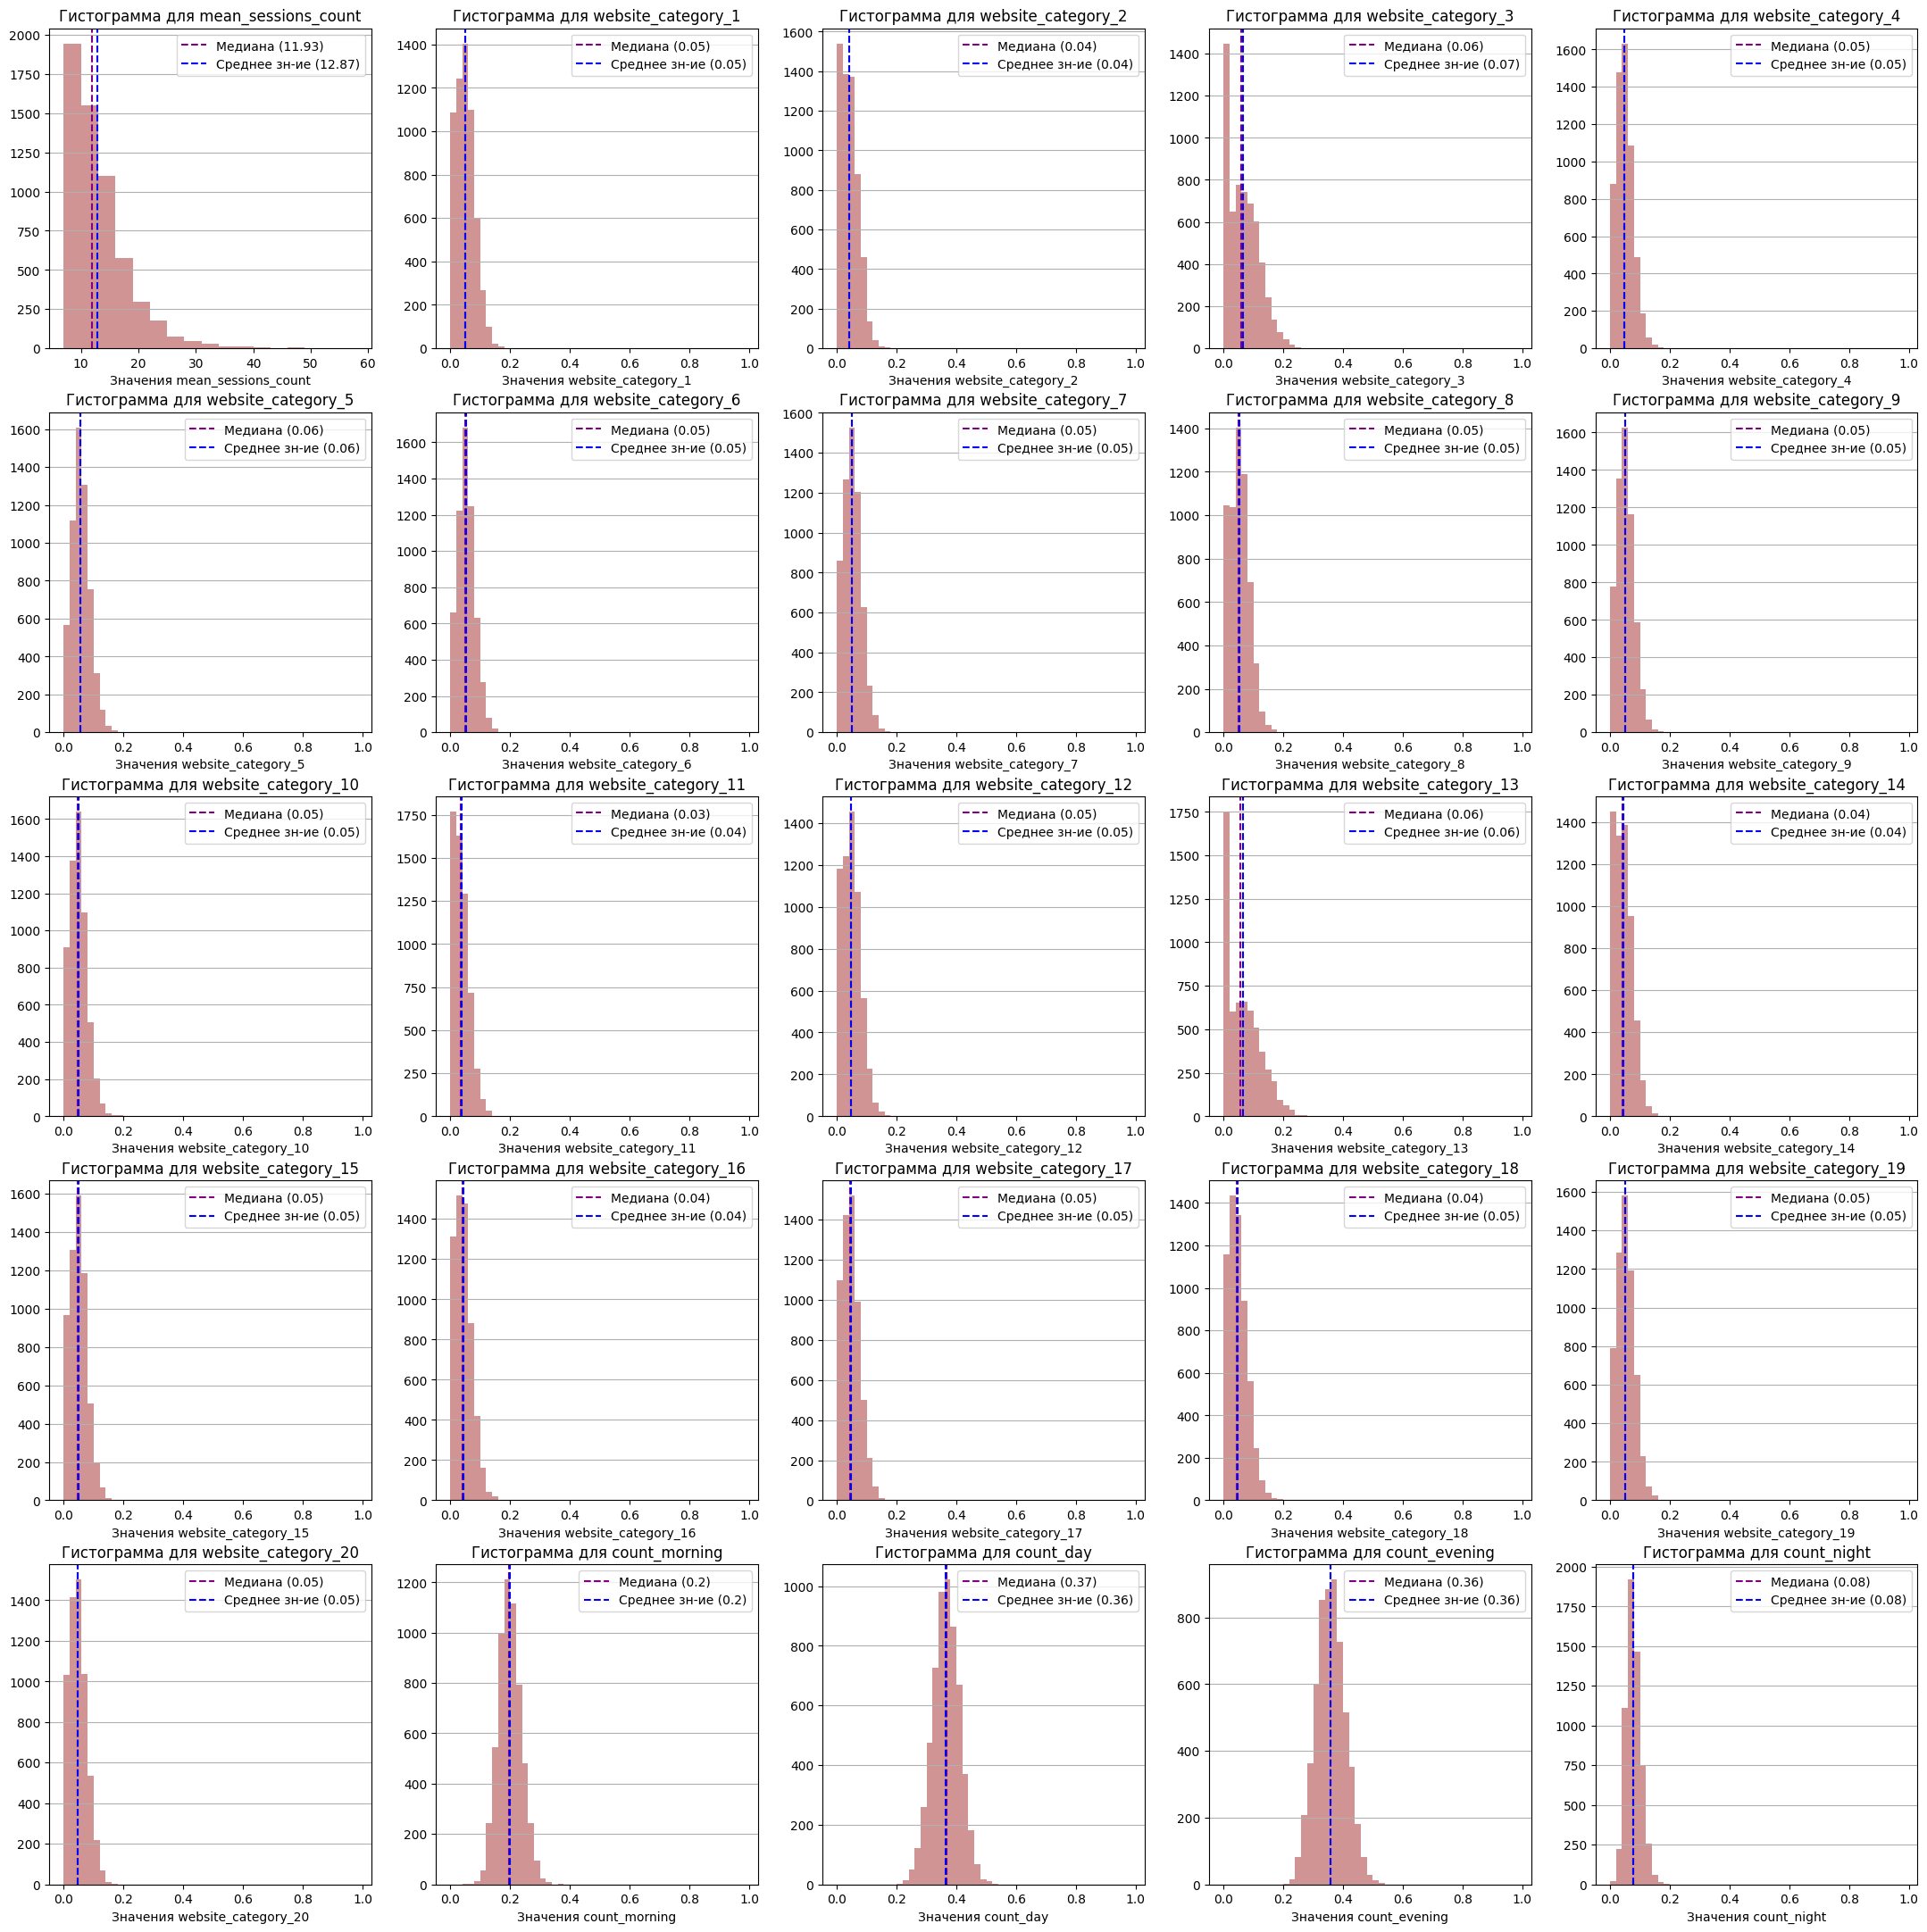

In [52]:
fig, axs = plt.subplots(5, 5, figsize=(27, 27))
for feature in range(len(num_cols) - 1):
    values = df[num_cols[feature]]
    name_feature = num_cols[feature]
    
    median = values.median()
    mean = values.mean()
    
    min_value = int(values.min())
    max_value = int(values.max()) + 1
    
    if max_value > 1:
            axs[feature // 5, feature % 5].hist(values, 
                                        color='brown',
                                        alpha=0.5,
                                        bins=range(min_value, max_value, 3)
                                       )
    else:
        axs[feature // 5, feature % 5].hist(values, 
                                            color='brown',
                                            alpha=0.5,
                                            bins=np.arange(min_value, max_value, 0.02)
                                           )
    axs[feature // 5, feature % 5].set_title(f'Гистограмма для {name_feature}')
    axs[feature // 5, feature % 5].set_xlabel(f'Значения {name_feature}')

    axs[feature // 5, feature % 5].axvline(median, label=f'Медиана ({round(median, 2)})', linewidth=1.5, color='purple', linestyle='--')
    axs[feature // 5, feature % 5].axvline(mean, label=f'Среднее зн-ие ({round(mean, 2)})', linewidth=1.5, color='blue', linestyle='--')
    
    axs[feature // 5, feature % 5].legend()
    axs[feature // 5, feature % 5].grid(axis='y')

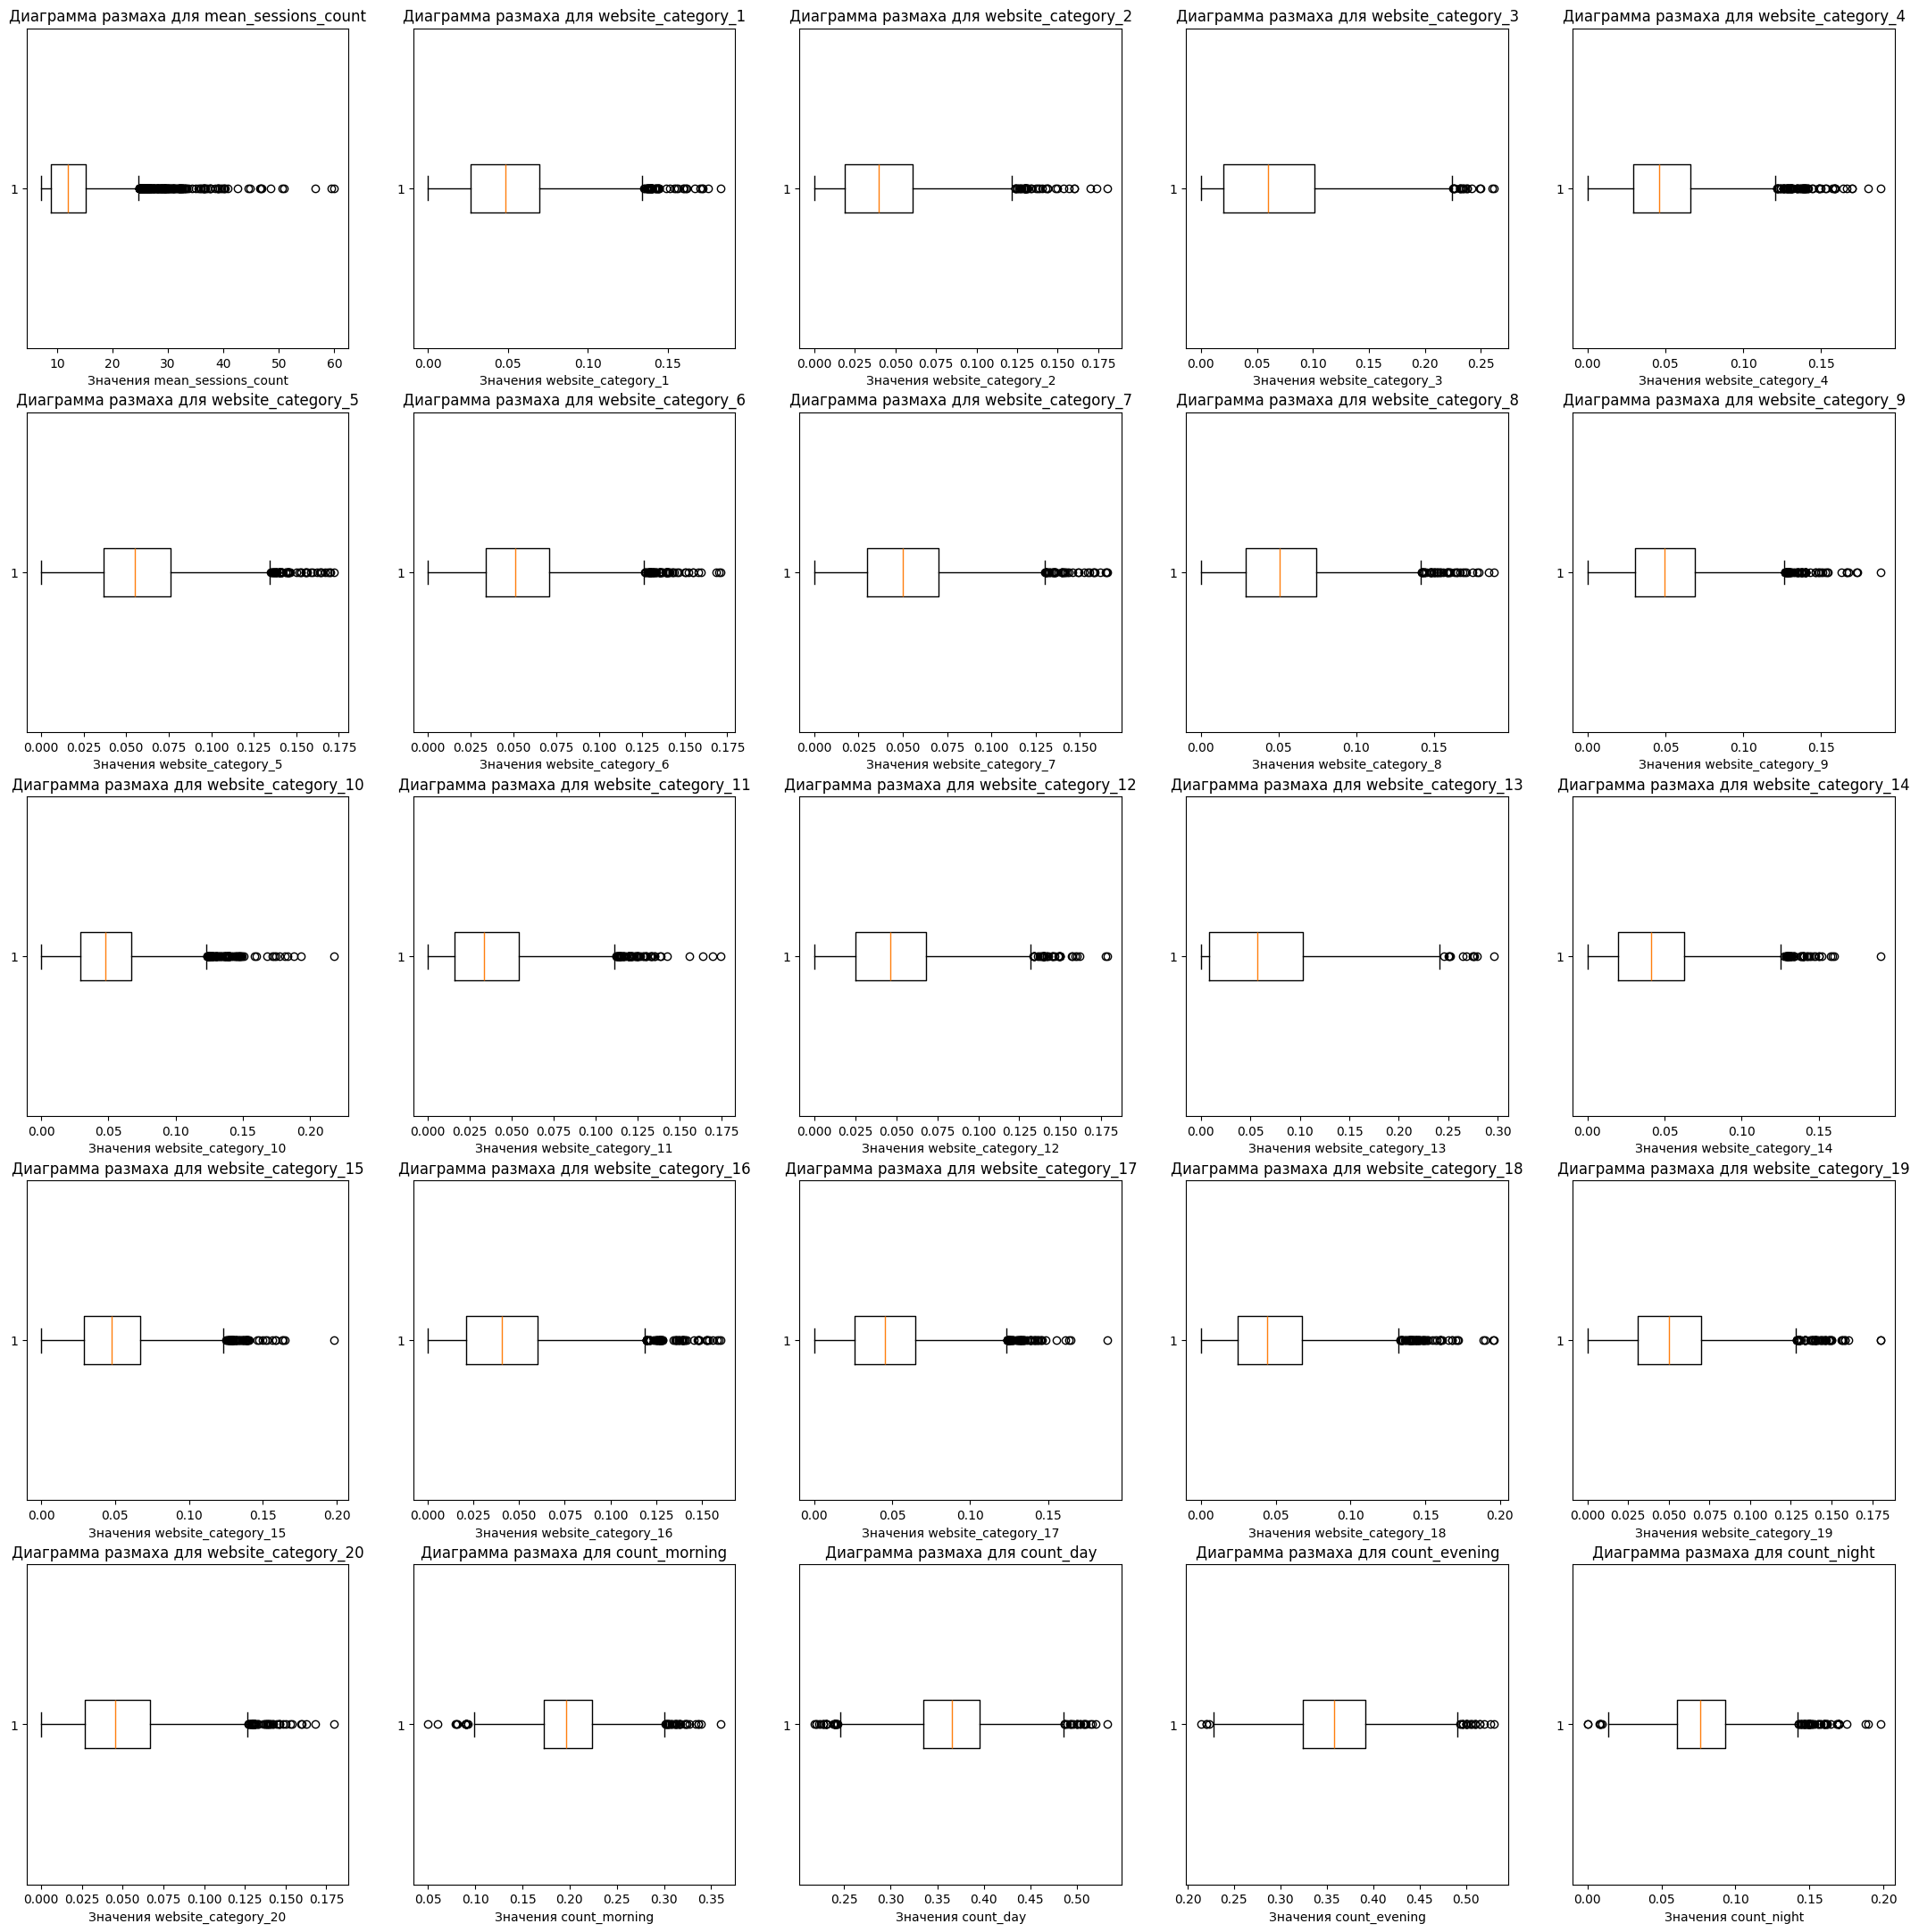

In [53]:
fig, axs = plt.subplots(5, 5, figsize=(27, 27))
for feature in range(len(num_cols) - 1):
    values = df[num_cols[feature]]
    name_feature = num_cols[feature]
    

    axs[feature // 5, feature % 5].boxplot(values, vert=False)
    axs[feature // 5, feature % 5].set_title(f'Диаграмма размаха для {name_feature}')
    axs[feature // 5, feature % 5].set_xlabel(f'Значения {name_feature}')

Все рассматриваемые признаки в являются сгенерированными нами. На некоторых диаграммах можно увидеть признаки наличия выбросов, например, на `website_category_9`, `website_category_10`, `website_category_13`, `website_category_14`, `website_category_15`, `website_category_17`, `website_category_19`, `website_category_20`, `count_morning` видно явно отстоящие от основной массы значения. Однако значения всех этих признаков были получены путем агрегирования, и каждое отстоящее значение было получено на основе большого количества данных о сессиях пользователей. Тогда, вероятнее всего, даже если выбросы и были в начальных данных, они "сгладились" за счет использования агрегирования.
Таким образом, выбросов в данных нет.

В категориальных признаках выбросов ак же нет, это было выяснено ранее.

Построим столбчатую диаграмму для дискретного признака `cloud_usage`.

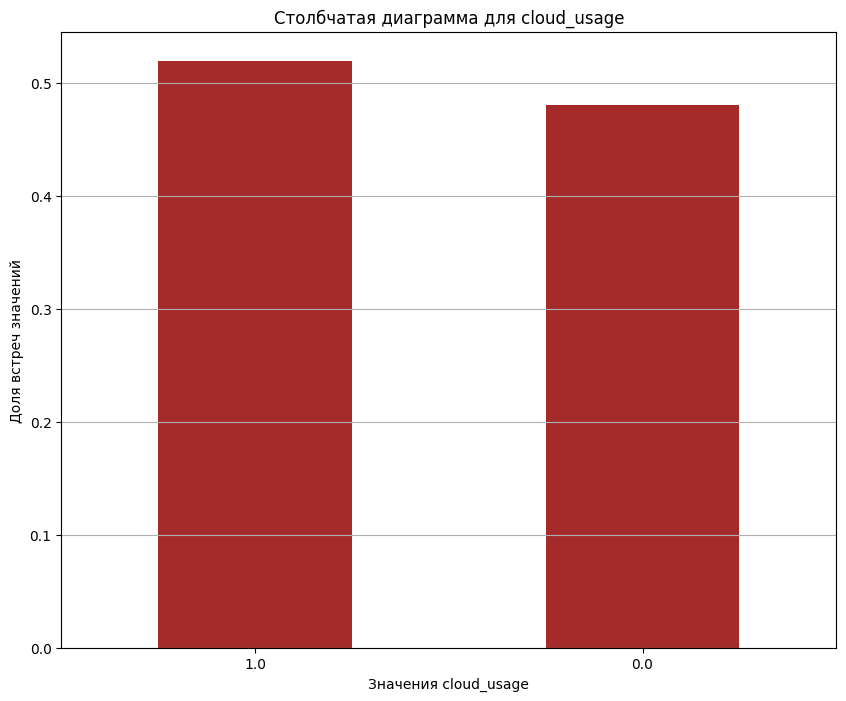

In [54]:
df['cloud_usage'].value_counts(normalize=True).plot(kind='bar',
                                      color='brown',
                                      rot=0,
                                      figsize=(10, 8),
                                      title=f'Столбчатая диаграмма для cloud_usage',
                                      xlabel='Значения cloud_usage',
                                      ylabel='Доля встреч значений'              
                                     ).grid(axis='y')

Выбросов в признаке `cloud_usage` нет.

#### Вывод по 2.8
По результатам анализа признаков на наличие выбросов, выбросов найдено не было.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.9-bullet"></a>
### 2.9 Корреляции

Построим матрицу корреляций сразу для всех признаков, проверим признаки на мультиколлинеарность и степень корреляции с целевой переменной.

Перед этим удалим признак `cloud_usage` из непрерывных признаков.

In [55]:
continuous_cols = num_cols.copy()
continuous_cols.remove('cloud_usage')

In [56]:
correlation = df.phik_matrix(interval_cols=num_cols)
correlation

,age_category,mean_sessions_count,website_category_1,website_category_2,website_category_3,website_category_4,website_category_5,website_category_6,website_category_7,website_category_8,website_category_9,website_category_10,website_category_11,website_category_12,website_category_13,website_category_14,website_category_15,website_category_16,website_category_17,website_category_18,website_category_19,website_category_20,most_popular_daytime,count_morning,count_day,count_evening,count_night,ads_activity,surf_depth,primary_device,cloud_usage
age_category,1.000000,0.065297,0.272933,0.406494,0.376865,0.416194,0.323572,0.311592,0.460505,0.412309,0.536089,0.387249,0.366315,0.503128,0.595733,0.411782,0.359040,0.507852,0.482861,0.452656,0.314134,0.466237,0.429629,0.578419,0.566752,0.686111,0.532861,0.367874,0.140736,0.183185,0.214420
mean_sessions_count,0.065297,1.000000,0.058225,0.000000,0.000000,0.047386,0.055327,0.000000,0.000000,0.028113,0.000000,0.047024,0.000000,0.037766,0.000000,0.000000,0.000000,0.065380,0.052142,0.047436,0.000000,0.091586,0.018170,0.150014,0.143166,0.144937,0.146330,0.367315,0.000000,0.020895,0.000000
website_category_1,0.272933,0.058225,1.000000,0.129134,0.309372,0.282594,0.052968,0.213751,0.173058,0.174349,0.038763,0.102491,0.116911,0.149000,0.474593,0.146219,0.121897,0.170327,0.071424,0.253037,0.078234,0.075539,0.096390,0.103901,0.052305,0.123900,0.029342,0.068881,0.008593,0.064539,0.055849
website_category_2,0.406494,0.000000,0.129134,1.000000,0.427643,0.072259,0.121507,0.126946,0.161864,0.230340,0.118785,0.041762,0.230594,0.135130,0.169112,0.330841,0.146868,0.143275,0.088430,0.190729,0.200680,0.114338,0.114154,0.164428,0.097118,0.163899,0.133525,0.119155,0.008272,0.053657,0.113993
website_category_3,0.376865,0.000000,0.309372,0.427643,1.000000,0.173118,0.094925,0.298151,0.106686,0.282148,0.084522,0.108644,0.240636,0.256743,0.182858,0.358544,0.092078,0.128791,0.354182,0.151637,0.247620,0.154222,0.054632,0.045163,0.051049,0.049301,0.066903,0.083750,0.032524,0.054300,0.029407
website_category_4,0.416194,0.047386,0.282594,0.072259,0.173118,1.000000,0.173431,0.130689,0.211674,0.160236,0.095902,0.082280,0.158276,0.159555,0.285853,0.063852,0.072803,0.091842,0.078090,0.119395,0.164341,0.136577,0.030791,0.000000,0.069367,0.029462,0.090001,0.069171,0.000000,0.041200,0.082464
website_category_5,0.323572,0.055327,0.052968,0.121507,0.094925,0.173431,1.000000,0.114033,0.250181,0.158330,0.069598,0.317975,0.159556,0.195049,0.090946,0.090298,0.302286,0.109631,0.159001,0.104794,0.288847,0.124710,0.074950,0.078440,0.121379,0.129377,0.000000,0.099856,0.048537,0.000000,0.048458
website_category_6,0.311592,0.000000,0.213751,0.126946,0.298151,0.130689,0.114033,1.000000,0.106690,0.129339,0.141763,0.159234,0.063706,0.181625,0.000000,0.098843,0.111800,0.106347,0.165321,0.114438,0.206553,0.111594,0.089585,0.137608,0.086848,0.143215,0.096793,0.095940,0.035862,0.016800,0.051204
website_category_7,0.460505,0.000000,0.173058,0.161864,0.106686,0.211674,0.250181,0.106690,1.000000,0.095822,0.271349,0.122829,0.076201,0.148679,0.108013,0.146130,0.033590,0.099281,0.179486,0.393450,0.119730,0.147297,0.126533,0.135369,0.075433,0.058079,0.082140,0.101483,0.058441,0.014350,0.120196
website_category_8,0.412309,0.028113,0.174349,0.230340,0.282148,0.160236,0.158330,0.129339,0.095822,1.000000,0.117052,0.127373,0.251629,0.049967,0.409448,0.211032,0.099160,0.109782,0.252554,0.204077,0.225571,0.052707,0.246504,0.220273,0.119340,0.162125,0.106094,0.089897,0.047600,0.000000,0.058690


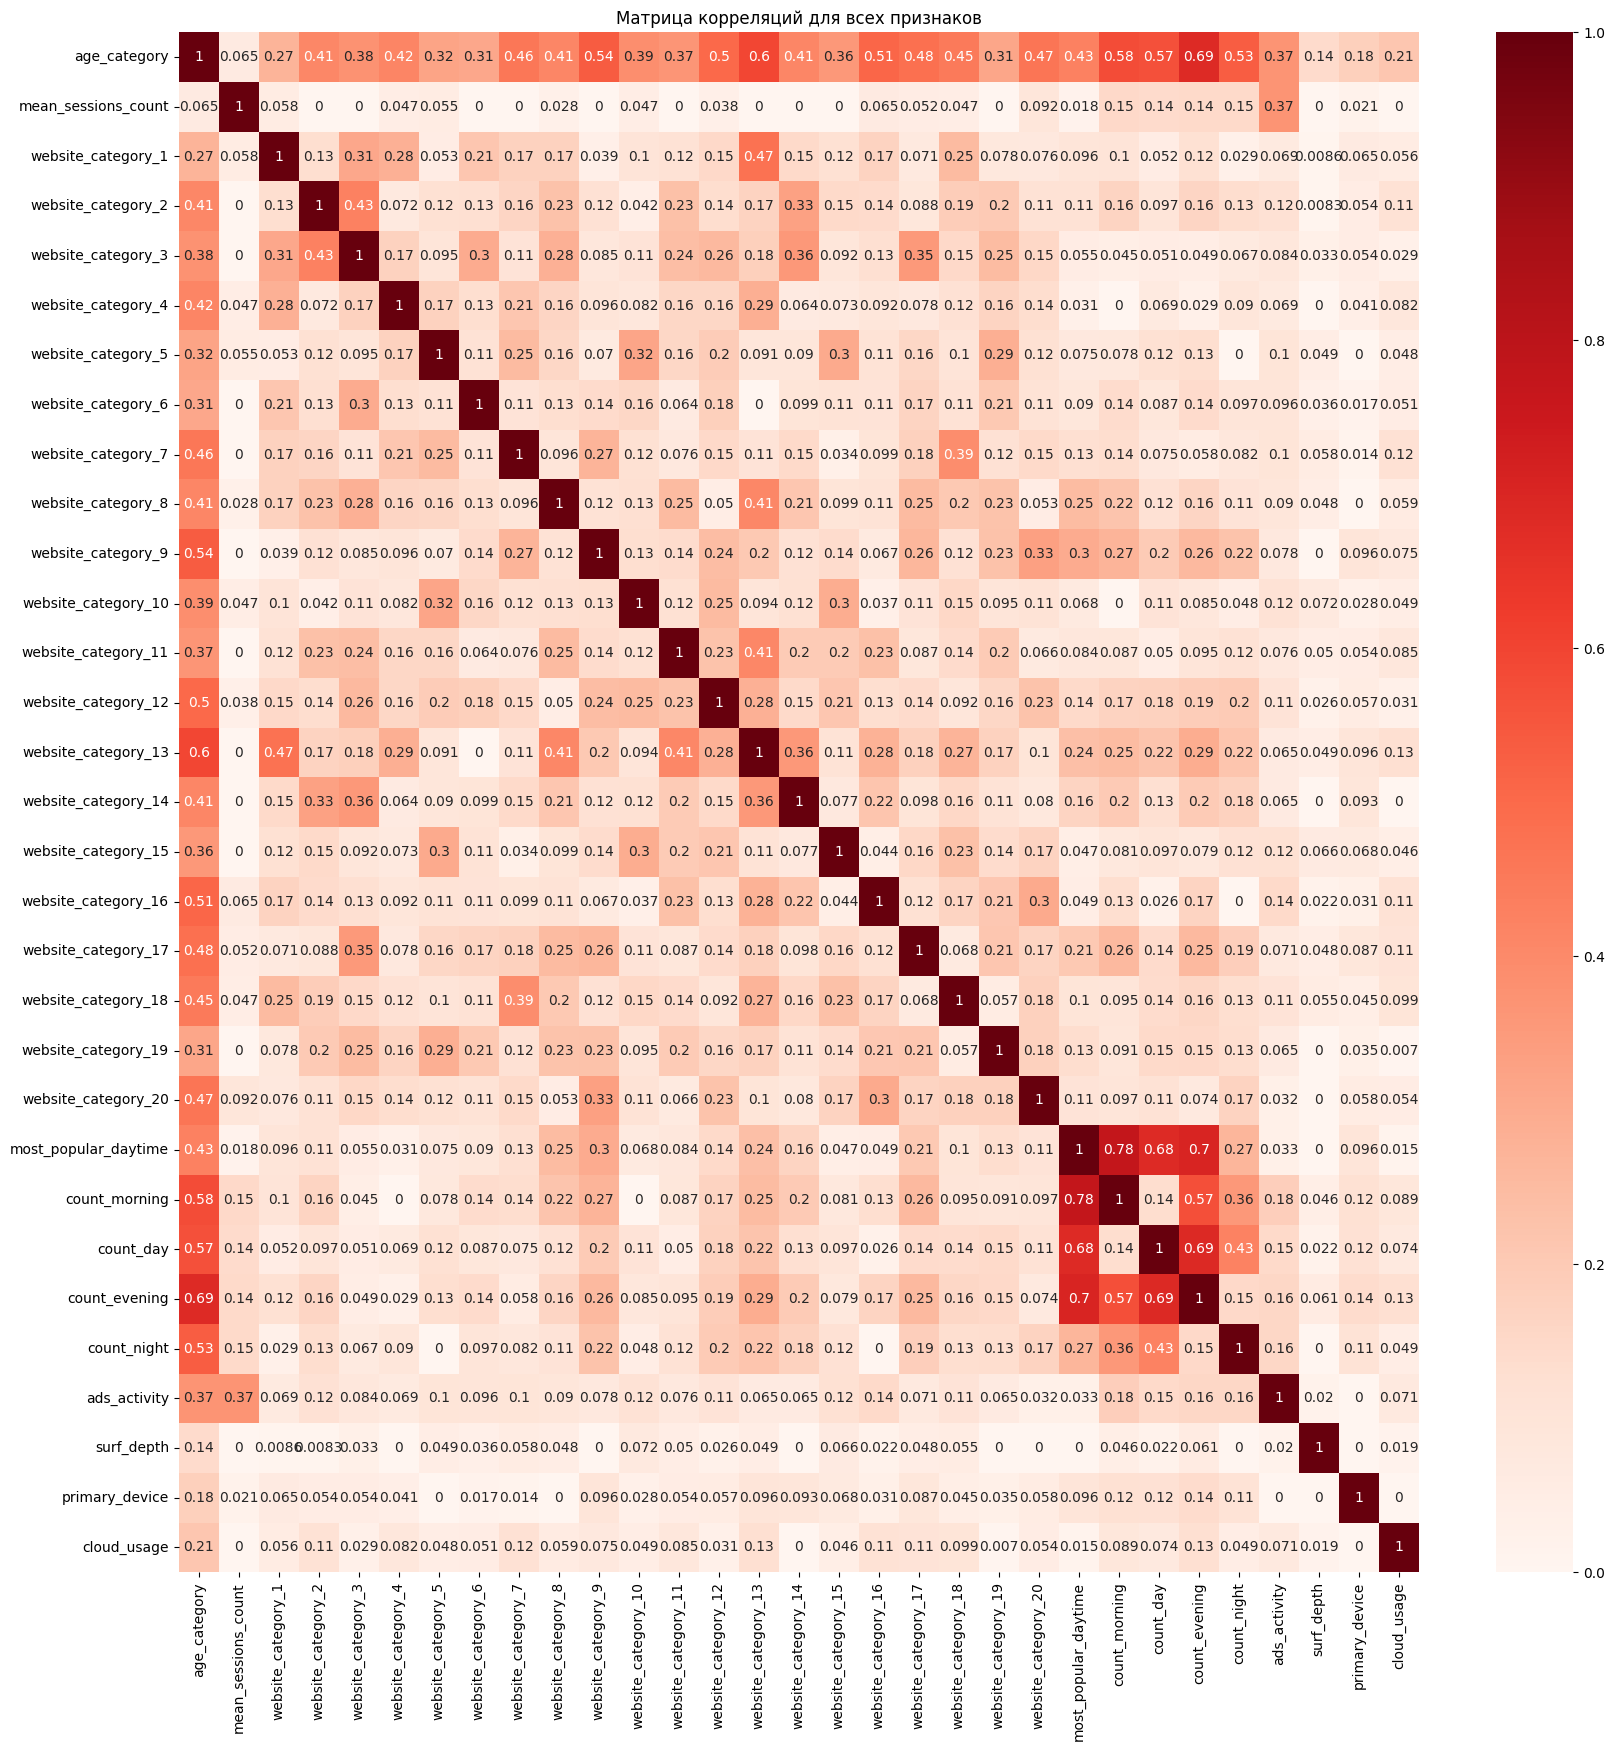

In [57]:
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, cmap='Reds', annot=True)
plt.title('Матрица корреляций для всех признаков')
plt.show()

Матрица корреляций говорит о том, что больше всего на целевую переменную влияют признаки, отвечающие за долевое распределение интересов пользователей по разным категориям сайтов - 0.5 и более корреляция с `website_category_9`, `website_category_12`, `website_category_13`, `website_category_16` и т.д., характеристика CTR `ads_activity` (0.37) и время, когда пользователь активен в сети - `count_morning/day/evening/night`, `most_popular_daytime` (0.43-0.7).

Сильно коррелирующих друг с другом признаков, у которых коэффициент корреляции больше 0.8, найдено не было, однако видно, что довольно сильно коррелирует признак `most_popular_daytime` с `count_morning/day/evening/night`, (0.68-0.78), что логично, так как эти признаки были построены из одних и тех же данных, но корреляция не критичная, поэтому этот признак удалять не будем.

#### Вывод по 2.9
Была построена матрица корреляций и создана на ее основе тепловая карта. Матрица корреляций показала, что больше всего на целевую переменную влияют признаки, отвечающие за долевой распределение интересов пользователей по разным категориям сайтов, характеристика CTR и время, когда пользователь активен в сети. Мультиколлинеарные признаки найдены не были.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Вывод по разделу 2

Опишем результаты выполнения раздела 2. 
- Охарактеризована общая информация о всех имеющихся датафреймах.
- Изучено распределение целевой переменной, выявлено, что наиболее распространенной возрастной категорией IT-компании являются взрослые люди в возрасте 56+ лет, наименее распространенной категорией - пользователи в возрасте 18-25 лет. Так как важно правильно распределять объекты по классам и не присваивать классам не принадлежащие им объекты, в качестве основной метрики была выбрана `F1-мера`, дополнительные метрики - `precision` и `recall`. 
- Проведена первичная предобработка по отдельности: на основе датафрейма `df_visits` были составлены новые признаки с наиболее активным временем суток у пользователей, долей интернет-активности для каждого времени суток, долевым распределением интересов пользователей по разным категориям сайтов, средним количеством сессий пользователей в день; в некоторых признаках были найдены дубликаты, которые были удалены. Выбросов и пропусков найдена в данных не было.
- Была рассмотрена основная информация о датасете и типах данных его признаков.
- Типы данных признакам были назначены корректно при загрузке датафрейма и работы над ним, все числовые признаки яявляются непрерывными. Был удален один явно ненужный, идентификационный признак, `user_id`.
- Были найдены и проанализированы пропуски в признаках `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`. Принято решение заменить их на моду у `cloud_usage` и категорию "Неизвестно" у остальных признаков.
- Было проанализировано количество уникальных знаений в категориальных признаках и определена стратегия работы с их кодированием. Было решено использовать:
	- One-Hot Encoding для `most_popular_daytime`, `surf_depth`;
	- Target Encoding для оставшихся признаков. 
- По результатам анализа признаков на наличие выбросов, выбросов найдено не было.
- Была построена матрица корреляций и создана на ее основе тепловая карта. Матрица корреляций показала, что больше всего на целевую переменную влияют признаки, отвечающие за долевой распределение интересов пользователей по разным категориям сайтов, характеристика CTR и время, когда пользователь активен в сети. Мультиколлинеарные признаки найдены не были.


<a class="anchor" id="3-bullet"></a>
## 3. Предобработка данных

<a class="anchor" id="3.1-bullet"></a>
### 3.1 Разделение данных на выборки

Разделим данные на выборки, в тестовую выборку определим 20% пользователей. Используем стратификацию по целевой переменной, чтобы сохранить пропорции классов.

In [58]:
X, y = df.drop('age_category', axis=1), df['age_category']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, 
                                                            y, 
                                                            test_size=TEST_SIZE, 
                                                            shuffle=True, 
                                                            random_state=RANDOM_SEED,
                                                            stratify=y)

Проверим размеры выборок.

In [59]:
print(f'''X_train_val: {X_train_val.shape}
y_train_val: {y_train_val.shape}
X_test: {X_test.shape}
y_test: {y_test.shape}''')

X_train_val: (4660, 30)
y_train_val: (4660,)
X_test: (1166, 30)
y_test: (1166,)


#### Вывод по 3.1

С использованием стратифицированного разделения данные были успешно разделены на train/val и test выборки.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="3.2-bullet"></a>
### 3.2 Создание пайплайнов и трансформера

Опишем логику работы с числовыми признаками:
- пропуски заменим на моду;
- выбросы обрабатывать не надо, так как их нет;
- масштабируем признаки с помощью `StandardScaler`.

Про масштабирование: в целом, все числовые признаки являются сгенерированными нами и находятся в одних масштабах (от 0 до 1), за исключением признака `mean_sessions_count`, поэтому данные для корректной работы надо привести к одному масштабу. Чтобы не зависеть от макстимальных и минимальных значений, используем StandardScaler, который приведет к среднему значению = 0 и стандартному отклонению = 1.

In [60]:
num_processing = Pipeline(steps=[
    ('null_to_moda', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

Опишем логику работы с числовыми признаками:

- пропуски заменим на категорию "Неизвестно";
- выбросы обрабатывать не надо, так как нет;
- применим кодирование.

Создадим 2 пайплайна для категориальных признаков, один будет работать с признаками для One-Hot Encoding, другой - с Target Encoding.

In [61]:
cat_processing_onehot = Pipeline(steps=[
    ('null_to_unknown', SimpleImputer(strategy='constant', fill_value='Неизвестно')),
    ('one_hot', OneHotEncoder())
])

In [62]:
cat_processing_target = Pipeline(steps=[
    ('null_to_unknown', SimpleImputer(strategy='constant', fill_value='Неизвестно')),
    ('target', TargetEncoder(target_type='multiclass'))
])

Создадим общий трансформер для обработки данных.

In [63]:
preprocessor = ColumnTransformer(transformers=[
    ('num_processing', num_processing, num_cols),
    ('cat_processing_onehot', cat_processing_onehot, cat_cols_onehot),
    ('cat_processing_target', cat_processing_target, cat_cols_target),
])

Был создан трансформер `preprocessor`, объединяющий основную логику работы с предобработкой данных и состоящий из 3 пайплайнов.

#### Вывод по 3.2

Было создано 3 пайплайна:
- 2 для обработки категориальных данных, чтобы была возможность применить разные виды кодирования;
- 1 для числовых данных - с обработкой пропусков и масштабированием с помощью StandardScaler.

Пайплайны были объединены в трансформере.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Вывод по разделу 3
В результате выполнения раздела 3 с использованием стратифицированного разделения данные были успешно разделены на train/val и test выборки. Было создано 3 пайплайна:
- 2 для обработки категориальных данных, чтобы была возможность применить разные виды кодирования;
- 1 для числовых данных - с обработкой пропусков и масштабированием с помощью StandardScaler.

Пайплайны были объединены в трансформере.

<a class="anchor" id="4-bullet"></a>
## 4. Обучение и оценка базовой модели

Перед созданием отдельных моделей добавим несколько общих для них элементов.

- создадим объект для кросс-валидации с 5 фолдами. Используем стратификацию по целевой переменной, чтобы сохранить пропорции классов.

In [64]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

- зададим метрики.

In [65]:
scoring = ['f1_macro', 'precision_macro', 'recall_macro']

- напишем функцию для построения матрицы ошибок и ее отображения с помощью тепловой карты.

In [66]:
def create_confusion_matrix(model_or_pipeline, y_train_val, X_train_val, is_model_fit, title, cv):
    labels = sorted(set(y_train_val))
   
    if not is_model_fit:
        y_pred = cross_val_predict(model_or_pipeline, X_train_val, y_train_val, cv=cv)
    else:   
        y_pred = model_or_pipeline.predict(X_train_val)
    cm = confusion_matrix(y_train_val, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(13,8))

    ax = sns.heatmap(cm, annot=True, fmt='.2f', cmap='YlGnBu')
    plt.title(title)
    plt.show()

- создадим функцию для создания трансформера, чтобы не передавать во все пайплайны один и тот же объект и не допустить ошибок.

In [67]:
def make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target):
    return ColumnTransformer(transformers=[
    ('num_processing', num_processing, num_cols),
    ('cat_processing_onehot', cat_processing_onehot, cat_cols_onehot),
    ('cat_processing_target', cat_processing_target, cat_cols_target),
])

- создадим список для составления сводной таблицы по результатам моделей.

In [68]:
for_result = {}

- определимся с моделями.

Будем использовать следующие модели:
- Dummy-модель в качестве базовой;
- Многоклассовую логистическую регрессию;
- One VS Rest с log reg, SVC с линейным и rbf-ядрами;
- One VS One с log reg, SVC с линейным и rbf-ядрами.

**Dummy-модель**

Начнем работу с обучения базовой модели. Создадим dummy-модель, которая будет предсказывать наиболее часто встречающйися класс.

In [69]:
cv_dummy = cross_validate(DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED), X_train_val, y_train_val, scoring=scoring, cv=cv)

C:\Users\Анна\Курс_Яндекс\multi-class\Practice\multi_class_venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Анна\Курс_Яндекс\multi-class\Practice\multi_class_venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Анна\Курс_Яндекс\multi-class\Practice\multi_class_venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

После обучения нам вышли предупреждения о том, что для каких-то классов модель не предсказал ни одного объекта, что закономерно, так как dummy-модель всегда предсказывает самый частый класс.

Проверим получившиеся метрики.

In [70]:
result_dummy = {"f1_macro": round(cv_dummy['test_f1_macro'].mean(), 2),
                "precision_macro": round(cv_dummy['test_precision_macro'].mean(), 2),
                "recall_macro": round(cv_dummy['test_recall_macro'].mean(), 2)}
result_dummy

{'f1_macro': 0.09, 'precision_macro': 0.06, 'recall_macro': 0.2}

Метрики dummy-модели, как и ожадилось, оказались очень низкими. Было использовано macro-усреднение, которое рассчитывает метрики для каждого класса, а потом полуенные значения усредняются, что позволяет учитывать каждый класс независимо от его размера. Так были найдены `f1_macro` = 0.09, `precision_macro` = 0.06, `recall_macro` = 0.2. Это говорит о том, что в среднем для каждого класса всего 6% объектов из тех, что модель посчитала как относящиеся к классу, действительно к нему относятся; модель находит примерно 20% объектов для каждого класса. F1 мера - гаромническое среднее между `precision` и `recall`, равно 9%, это говорит о плохом качестве модели и сильном дисбалансе между `precision` и `recall`.   

Построим матрицу ошибок, чтобы посмотреть, где модель ошибается.

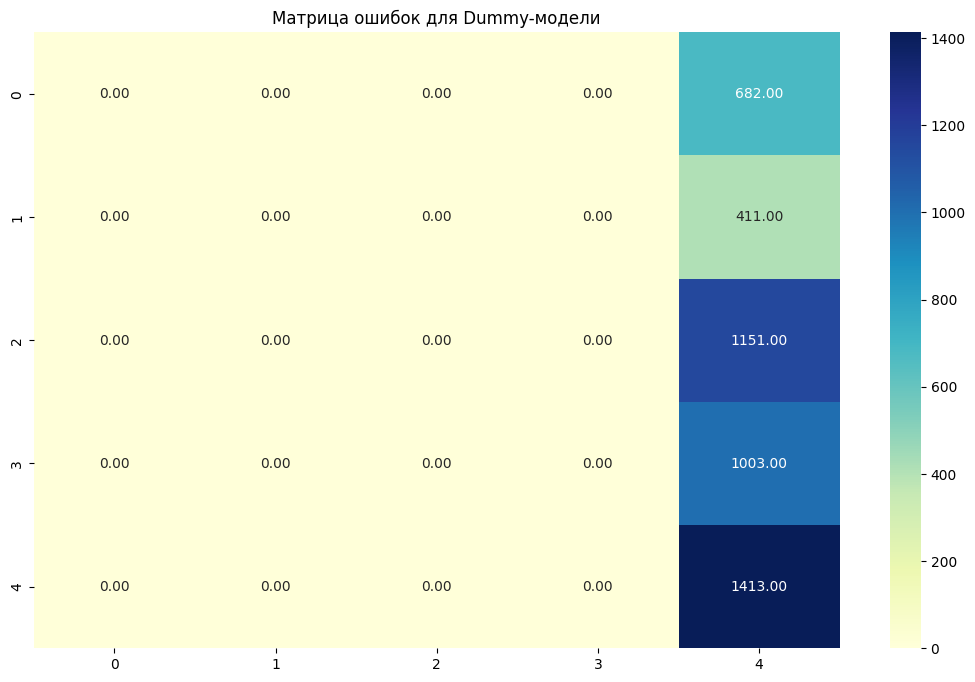

In [71]:
create_confusion_matrix(DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED), 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для Dummy-модели',
                        cv)

По матрице ошибок для Dummy-модели можно увидеть, что самым частым классом оказался 4, поэтому цвета видны только в правокм крайнем столбце. Во всех классах, кроме четвертого, количество ошибок равно количеству объектов в этом классе. Такая модель не справялется с совершением предсказаний.

Добавим результаты в словарь.

In [72]:
for_result['Dummy'] = result_dummy['f1_macro'], result_dummy['precision_macro'], result_dummy['recall_macro']

**Многоклассовая логистическая регрессия**

Создадим пайплайн для работы с многоклассовой логистической регрессией. На данном этапе не станем подбирать параметры, сделаем это в следующих пунтках, установим только `random_state` для воспроизводимости, `class_weight` для работы с несбалансированными данными, явно укажем метод оптимизации `lbfgs` и добавим многоклассовую логику с помощью `multinomial`. Особенности многоклассовой логистической регрессии для данной работы, которые стоит учесть:
- ищет линейные гиперплоскости, может не подходить для нелинейных границ между классами;
- работает сразу со множеством классов, обучает не десятки моделей, а одну;
- чувствительно к мультиколлинеарности.

In [74]:
pipeline_multiclass_log_reg = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('multiclass_log_reg', LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight="balanced", random_state=RANDOM_SEED))
])
cv_multiclass_log_reg = cross_validate(pipeline_multiclass_log_reg, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы многоклассовой логистической регрессии.

In [75]:
result_multiclass_log_reg = {"f1_macro": round(cv_multiclass_log_reg['test_f1_macro'].mean(), 2),
                             "precision_macro": round(cv_multiclass_log_reg['test_precision_macro'].mean(), 2),
                             "recall_macro": round(cv_multiclass_log_reg['test_recall_macro'].mean(), 2)}
result_multiclass_log_reg

{'f1_macro': 0.81, 'precision_macro': 0.81, 'recall_macro': 0.82}

Метрики стали намного лучше, по сравнению с Dummy-моделью: `f1_macro` увеличилась и стала равна 0.81, баланс между метриками `precision_macro` = 0.81 и `recall_macro` = 0.82 достаточно хороший - ни одна из метрик не перевешивает, их значения достаточно высокие - примерно в 82% случаев модель может правильно выделять объекты целевых классов из общей массы объектов, принадлежащих классу, и в среднем из сделанных предсказаний в 81% случаев правильно предсказывать класс объекта.

Построим матрицу ошибок, чтобы посмотреть, где модель ошибается.

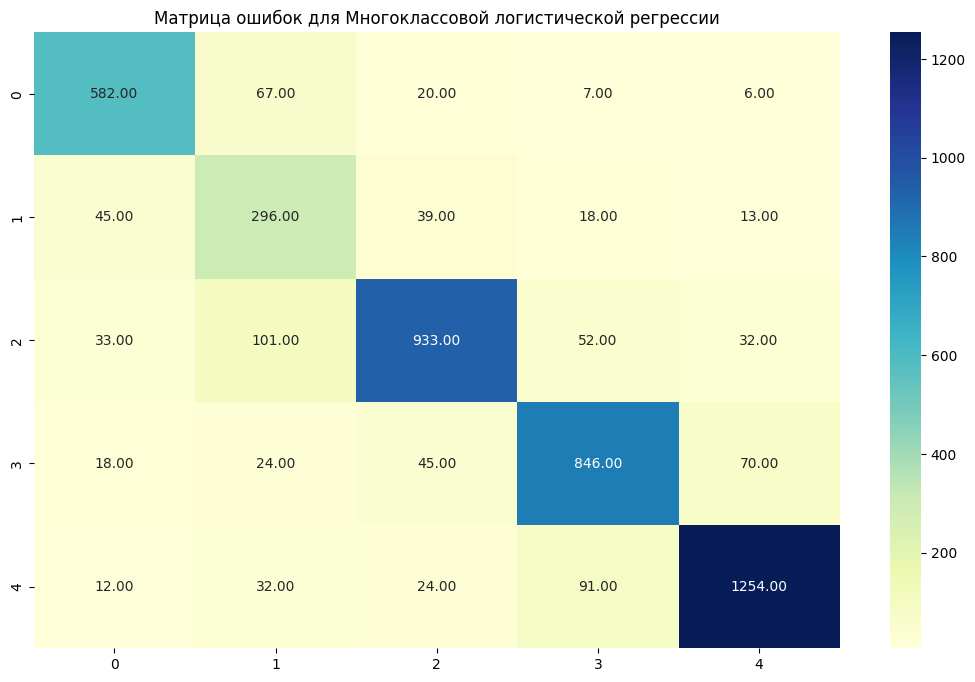

In [76]:
create_confusion_matrix(pipeline_multiclass_log_reg, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для Многоклассовой логистической регрессии',
                        cv)

Матрица ошибок стала выглядеть уже правильнее - большее сгущение темных оттенков присуще главной диагонали, однако можно увидеть, что из-за того, что логистическая регрессия старается минимизировать общую ошибку для всех примеров, модель смещается в сторону классов с наибольшей численностью и получается, что лучше всего определяется снова 4 класс, а хуже всего - 1-ый, содержащий наименьшее количество объектов.

In [77]:
for_result['Многоклассовая лог.рег.'] = result_multiclass_log_reg['f1_macro'], result_multiclass_log_reg['precision_macro'], result_multiclass_log_reg['recall_macro']

**OVR с логистической регрессией**

Используем способ решения многоклассовых задач One-vs-Rest, который создает столько моделей, сколько дано классов и учится отличать каждый класс от всех других. Особенности, которые могут оказаться важными для этой работы:
- быстрая скорость работы, простота реализации;
- плохо работает с несбалансированными данными.

In [78]:
pipeline_OVR_log_reg = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVR_log_reg', OneVsRestClassifier(LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)))
])
cv_OVR_log_reg = cross_validate(pipeline_OVR_log_reg, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы OVR с логистической регрессией.

In [79]:
result_OVR_log_reg = {"f1_macro": round(cv_OVR_log_reg['test_f1_macro'].mean(), 2),
                      "precision_macro": round(cv_OVR_log_reg['test_precision_macro'].mean(), 2),
                      "recall_macro": round(cv_OVR_log_reg['test_recall_macro'].mean(), 2)}
result_OVR_log_reg

{'f1_macro': 0.81, 'precision_macro': 0.8, 'recall_macro': 0.81}

Результаты по основной метрике F1 оказались наравне с многоклассовой логистической регрессией, по дополинтельным метрикам немного хуже. Но в целом остались на том же уровне - `precision` и `recall` достаточно хорошо сбалансированы, имеют сравнительно высокие показатели. 

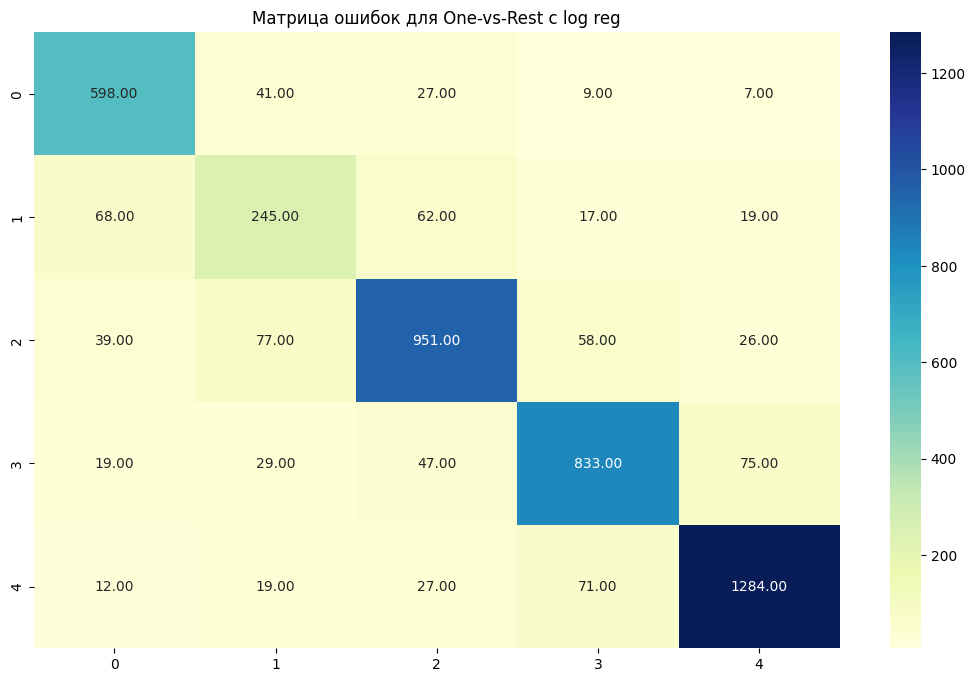

In [80]:
create_confusion_matrix(pipeline_OVR_log_reg, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-Rest с log reg',
                        cv)

Матрица иллюстрирует особенность OvR - идет смещение в сторону наиболее "больших" классов, а "наименьший" первый класс модель предсказывать не умеет. 

In [81]:
for_result['One-vs-Rest с лог.рег.'] = result_OVR_log_reg['f1_macro'], result_OVR_log_reg['precision_macro'], result_OVR_log_reg['recall_macro']

**OVR с SVC с линейным ядром**

Используем в качестве базовой модели для OVR - SVC с линейным ядром. Вероятнее, далее оставим модель только с нелинейным ядром, так как в условии сказано, что некоторые входные признаки могут быть связаны с целевой переменной нелинейно, но используем и ее для сравнения.

In [82]:
pipeline_OVR_SVC_linear = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVR_SVC_linear', OneVsRestClassifier(SVC(kernel='linear', random_state=RANDOM_SEED)))
])
cv_OVR_SVC_linear = cross_validate(pipeline_OVR_SVC_linear, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы модели.

In [83]:
result_OVR_SVC_linear = {"f1_macro": round(cv_OVR_SVC_linear['test_f1_macro'].mean(), 2),
                           "precision_macro": round(cv_OVR_SVC_linear['test_precision_macro'].mean(), 2),
                           "recall_macro": round(cv_OVR_SVC_linear['test_recall_macro'].mean(), 2)}
result_OVR_SVC_linear

{'f1_macro': 0.78, 'precision_macro': 0.81, 'recall_macro': 0.78}

Закономерность в метриках остается такая же, как в предыдущих моделях, при этом их значения немного ухудшились.

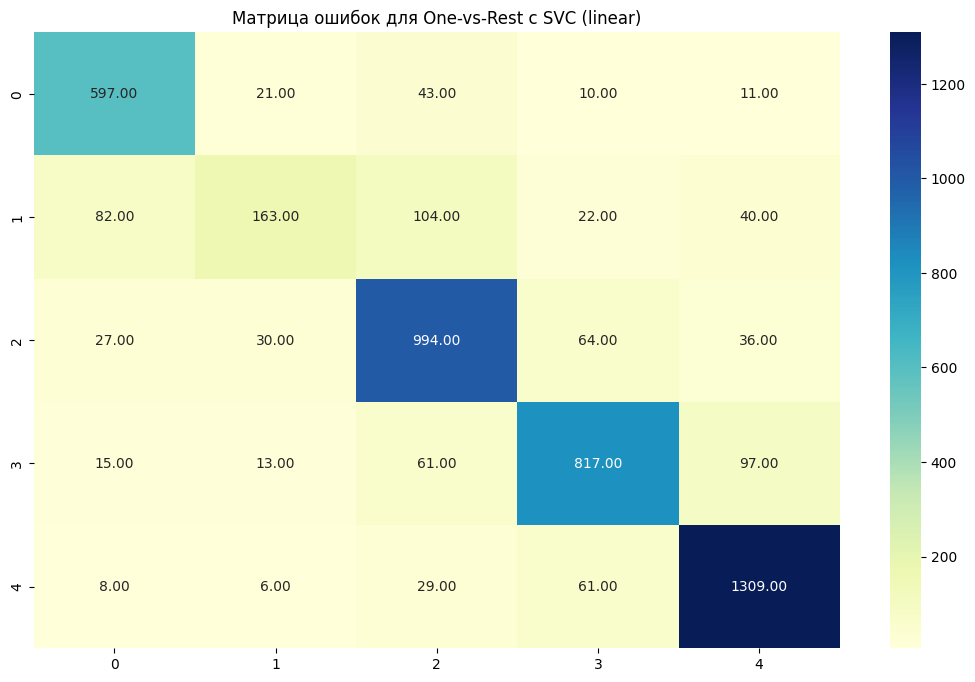

In [84]:
create_confusion_matrix(pipeline_OVR_SVC_linear, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-Rest с SVC (linear)',
                        cv)

Матрица ошибок так же говорит о перевесе в сторону больших классов. Чуть лучше, чем у предыдущих моделей, был предсказан второй класс.

In [85]:
for_result['One-vs-Rest с SVC (linear)'] = result_OVR_SVC_linear['f1_macro'], result_OVR_SVC_linear['precision_macro'], result_OVR_SVC_linear['recall_macro']

**OVR с SVC с RBF ядром**

В условиях к проекту сказано, что некоторые входные признаки могут быть связаны с целевой переменной нелинейно, поэтому так же используем RBF-ядро, которое используется для разделение сложных форм классов и формирует границы на основе радиальных функций.

In [86]:
pipeline_OVR_SVC_rbf = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVR_SVC_rbf', OneVsRestClassifier(SVC(kernel='rbf', random_state=RANDOM_SEED)))
])
cv_OVR_SVC_rbf = cross_validate(pipeline_OVR_SVC_rbf, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы модели.

In [87]:
result_OVR_SVC_rbf = {"f1_macro": round(cv_OVR_SVC_rbf['test_f1_macro'].mean(), 2),
                           "precision_macro": round(cv_OVR_SVC_rbf['test_precision_macro'].mean(), 2),
                           "recall_macro": round(cv_OVR_SVC_rbf['test_recall_macro'].mean(), 2)}
result_OVR_SVC_rbf

{'f1_macro': 0.9, 'precision_macro': 0.91, 'recall_macro': 0.9}

Метрики значительно улушились по сравнению с предыдущими метриками моделей: `f1_macro` и `recall_macro` стали равны 0.9, `precision_macro` = 0.91.  Это связано с тем, что при условии наличия нелинейных связей между признаками и целевой переменной, было использовано RBF-ядро, которое нашло те зависимости, которые не смогли распознать линейные модели и ядра. Данные оказались хорошо сбалансированы, модель в среднем в 91% случаев не ошибается в своих предсказаниях и может выделять 90% объектов, принадлежащих классам. 

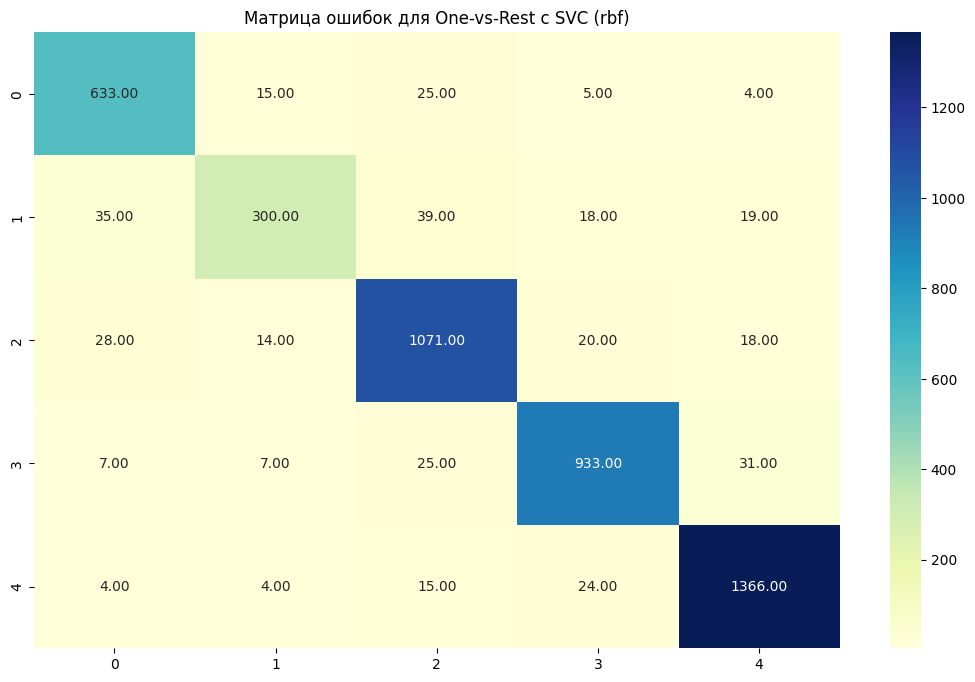

In [88]:
create_confusion_matrix(pipeline_OVR_SVC_rbf, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-Rest с SVC (rbf)',
                        cv)

Матрица ошибок стала выглядеть правильнее - все клетки, кроме главное диагонали, близки к максимально светлому оттенку, модель стала лучше справляться с редким первым классом.

In [92]:
for_result['One-vs-Rest с SVC (rbf)'] = result_OVR_SVC_rbf['f1_macro'], result_OVR_SVC_rbf['precision_macro'], result_OVR_SVC_rbf['recall_macro']

**OVO с логистической регрессией**

Используем способ решения многоклассовых задач One-vs-One, который создает модели для каждой пары классов. Особенности, которые могут оказаться важными для этой работы:
- лучше улавливает границу между классами, даже если они сильно похожи;
- меньшее влияние дисбаланса за счет рассмотрения каждой пары в отдельности;
- может дольше работать, так как количество моделей увеличивается пропорционально количеству классов.

In [93]:
pipeline_OVO_log_reg = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVO_log_reg', OneVsOneClassifier(LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)))
])
cv_OVO_log_reg = cross_validate(pipeline_OVO_log_reg, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы модели.

In [94]:
result_OVO_log_reg = {"f1_macro": round(cv_OVO_log_reg['test_f1_macro'].mean(), 2),
                           "precision_macro": round(cv_OVO_log_reg['test_precision_macro'].mean(), 2),
                           "recall_macro": round(cv_OVO_log_reg['test_recall_macro'].mean(), 2)}
result_OVO_log_reg

{'f1_macro': 0.82, 'precision_macro': 0.82, 'recall_macro': 0.83}

Метрики схожи с результатами многоклассовой логистической регрессии и OVR с лог.рег. Сбалансированность `precision` и `recall` неплохая, значения метрик относительно высокие.

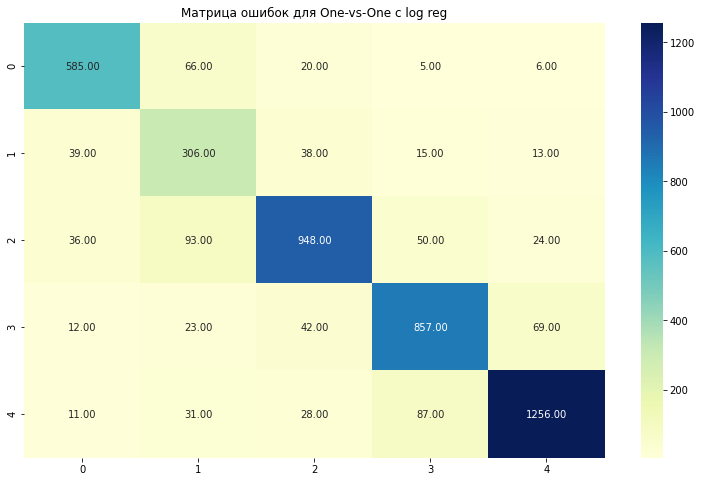

In [95]:
create_confusion_matrix(pipeline_OVO_log_reg, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-One с log reg',
                        cv
                       )

За счет рассмотрения каждых классов в парах, модель чуть лучше стала предсказывать малочисленный класс 1, но все еще лидирует наиболее многочисленный класс 4.

In [96]:
for_result['One-vs-One с лог.рег.'] = result_OVO_log_reg['f1_macro'], result_OVO_log_reg['precision_macro'], result_OVO_log_reg['recall_macro']

**OVO с SVC с линейным ядром**

Из той же логики, что и с SVC с линейным ядром у OVR, посмотрим на результаты OVO.

In [97]:
pipeline_OVO_SVC_linear = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVO_SVC_linear', OneVsOneClassifier(SVC(kernel='linear', random_state=RANDOM_SEED)))
])
cv_OVO_SVC_linear = cross_validate(pipeline_OVO_SVC_linear, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы модели.

In [98]:
result_OVO_SVC_linear = {"f1_macro": round(cv_OVO_SVC_linear['test_f1_macro'].mean(), 2),
                           "precision_macro": round(cv_OVO_SVC_linear['test_precision_macro'].mean(), 2),
                           "recall_macro": round(cv_OVO_SVC_linear['test_recall_macro'].mean(), 2)}
result_OVO_SVC_linear

{'f1_macro': 0.82, 'precision_macro': 0.83, 'recall_macro': 0.82}

Метрики опять же оказались схожими с OVO с логистической регрессией - хорошо сбалансированы, в 83% случаев модель не ошибается с предсказанием, в 82% случаев может находить объекты целевого класса.

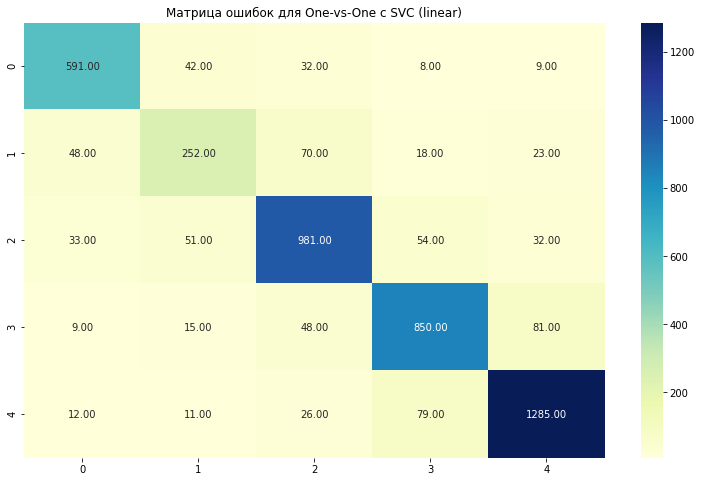

In [99]:
create_confusion_matrix(pipeline_OVO_SVC_linear, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-One с SVC (linear)',
                        cv
                       )

Модель игнорирует первый класс и не умеет его предсказывать. Вероятно, это связано с тем, что при работе моделей с двумя классами, они не смогли провести линейную гиперплоскость в исходном пространстве для разделения классов из-за наличия нелинейности.

In [100]:
for_result['One-vs-One с SVC (linear)'] = result_OVO_SVC_linear['f1_macro'], result_OVO_SVC_linear['precision_macro'], result_OVO_SVC_linear['recall_macro']

**OVO с SVC с RBF**

Используем нелинейное ядро для SVC, которое сможет работать с нелинейными зависимостями.

In [101]:
pipeline_OVO_SVC_rbf = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVO_SVC_rbf', OneVsOneClassifier(SVC(kernel='rbf', random_state=RANDOM_SEED)))
])
cv_OVO_SVC_rbf = cross_validate(pipeline_OVO_SVC_rbf, X_train_val, y_train_val, scoring=scoring, cv=cv)

Получим результаты работы модели.

In [102]:
result_OVO_SVC_rbf = {"f1_macro": round(cv_OVO_SVC_rbf['test_f1_macro'].mean(), 2),
                      "precision_macro": round(cv_OVO_SVC_rbf['test_precision_macro'].mean(), 2),
                      "recall_macro": round(cv_OVO_SVC_rbf['test_recall_macro'].mean(), 2)}
result_OVO_SVC_rbf

{'f1_macro': 0.9, 'precision_macro': 0.91, 'recall_macro': 0.9}

Метрики оказались равны лучшему результату, который достигла OVR модель с SVC (rbf). Метрики показали точно такие же значения.

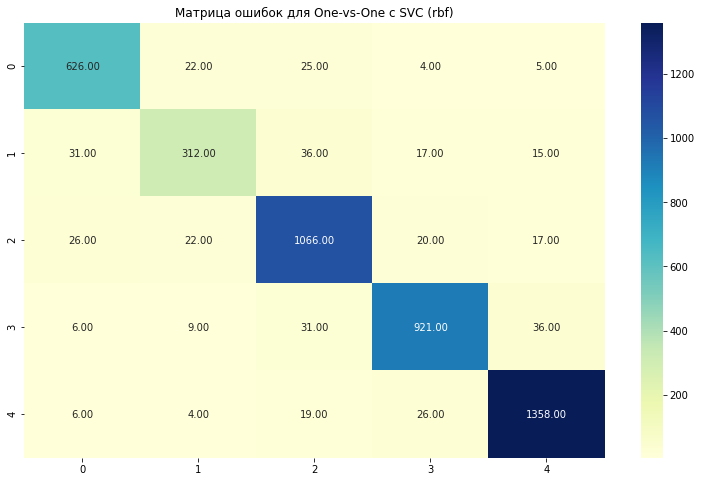

In [103]:
create_confusion_matrix(pipeline_OVO_SVC_rbf, 
                        y_train_val, 
                        X_train_val, 
                        False,
                        'Матрица ошибок для One-vs-One с SVC (rbf)',
                        cv
                       )

Матрица ошибок чуть улучшилась, по сравнению с предыдущим лучшим результатом, если смотреть на умение модели предсказывать наименьший класс.

In [104]:
for_result['One-vs-One с SVC (rbf)'] = result_OVO_SVC_rbf['f1_macro'], result_OVO_SVC_rbf['precision_macro'], result_OVO_SVC_rbf['recall_macro']

**Сведем данные всех моделей в одну таблицу**

При этом отсортируем модели по возрастанию по основной метрике `F1-мера`.

In [105]:
result = pd.DataFrame(for_result).sort_values(by=0, axis=1, ascending=True)
result.insert(0, 'metrics', scoring)
result

,metrics,Dummy,One-vs-Rest с SVC (linear),Многоклассовая лог.рег.,One-vs-Rest с лог.рег.,One-vs-One с лог.рег.,One-vs-One с SVC (linear),One-vs-Rest с SVC (rbf),One-vs-One с SVC (rbf)
0,f1_macro,0.09,0.78,0.81,0.81,0.82,0.82,0.90,0.90
1,precision_macro,0.06,0.81,0.81,0.80,0.82,0.83,0.91,0.91
2,recall_macro,0.20,0.78,0.82,0.81,0.83,0.82,0.90,0.90


По основной метрике `F1` лучшими моделями оказались модели с нелинейным ядром у SVC: OvR с SVC, у которой ядро RBF, а также OvO с SVC, у которой ядро RBF, их значение `F1_macro` оказались равны 0.9, `precision` = 0.91, `recall` = 0.9. Их метрики хорошо сбалансированные, достаточно высокие и говорят о том, что в 91% случаев модель не ошибается в своих предсказаниях и умеет выделять 90% объектов из целевого класса. 

### Вывод по разделу 4

Были обучены 8 моделей, получены для них значения метрик `F1-мера`, `precision` и `recall`, построены матрицы ошибок и тепловые карты для их визуализации. Лучшими моделями по результатам обучений по метрике `F1-мера` оказались One-vs-Rest с SVC, у которой ядро RBF и One-vs-One с SVC, у которой ядро RBF, для них значение метрики равно 0.9.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="5-bullet"></a>
## 5. Создание и отбор признаков

Применим фильтрационные методы и методы-обертки для отыскания оптимального набора признаков.

<a class="anchor" id="5.1-bullet"></a>
### 5.1 Фильтрационные методы 

Проверим корреляцию признаков с целевой переменной с помощью метрики "взаимной информации" (MI), которая измерит взаимозависимость признака и целевой переменной и покажет, сколько информации мы получаем о целевой переменной, наблюдая переменную с признаком.

Так же используем phik, определяющий степень корреляции между переменными.

Оба подхода являются допустимыми и для линейных, и для нелинейных зависимостей.

**Использование MI**

In [106]:
prep = make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)
prep.fit(X_train_val, y_train_val)
X_train_val_transformed = pd.DataFrame(prep.transform(X_train_val), columns=prep.get_feature_names_out())

transformed_col_names = []

for column in prep.get_feature_names_out():
    transformed_col_names.append(column[column.index('__') + 2:])

In [107]:
mi_scores = mutual_info_classif(X_train_val_transformed, y_train_val)
mi_scores = pd.Series(mi_scores, index=transformed_col_names)
mi_scores= mi_scores.sort_values(ascending=False)
mi_scores

count_evening                 0.280906
count_morning                 0.206182
website_category_13           0.178626
count_night                   0.173151
website_category_12           0.173095
count_day                     0.163349
website_category_16           0.163238
website_category_9            0.162017
most_popular_daytime_вечер    0.146299
website_category_20           0.142819
website_category_7            0.141032
most_popular_daytime_день     0.138800
website_category_17           0.133149
website_category_18           0.118943
website_category_3            0.113923
website_category_8            0.108694
website_category_4            0.106939
website_category_14           0.103916
website_category_15           0.101925
website_category_10           0.101399
website_category_2            0.099728
website_category_19           0.088018
website_category_11           0.087230
website_category_6            0.074371
website_category_5            0.074325
mean_sessions_count      

Метрика говорит о том, что наибольшее количество информации о целевой переменной мы получаем, наблюдая долю интернет-активности пользователей по времени суток, категории посещаемых сайтов, наиболее популярное время для проведения в интернете, среднее количество сессий в день.

**Использование phik**

In [108]:
continuous_cols_phik = []
for column in prep.get_feature_names_out():
    if column[column.index('__') + 2:] in continuous_cols or column[column.index('__') + 2:] in cat_cols_target:
        continuous_cols_phik.append(column)
X_train_val_transformed['age_category'] = y_train_val

In [109]:
X_train_val_transformed.phik_matrix(interval_cols=continuous_cols_phik).iloc[:-1, -1].sort_values(ascending=False)

num_processing__website_category_6                   0.096665
num_processing__website_category_13                  0.076224
num_processing__website_category_7                   0.074089
num_processing__count_morning                        0.056384
cat_processing_target__primary_device_2              0.046726
cat_processing_target__primary_device_0              0.046726
cat_processing_target__primary_device_4              0.046726
cat_processing_target__primary_device_3              0.046726
cat_processing_target__primary_device_1              0.046726
num_processing__website_category_17                  0.040299
num_processing__website_category_12                  0.039501
num_processing__count_night                          0.035954
num_processing__website_category_3                   0.033332
num_processing__website_category_2                   0.027116
cat_processing_onehot__surf_depth_поверхностно       0.022691
num_processing__website_category_16                  0.021521
cat_proc

Phik говорит о том, что больше всего целевая переменная коррелирует с категориями сайтов, которые посещают пользователи, основными устройствами пользователя для выхода в Интернет, наиболее популярным временем для проведения в интернете, глубиной перехода пользователя по сайтам во время одной сессии.

По результатам фильтрационных методов наиболее значимыми признаками оказались:
- `count_morning`;  
- `count_night`;
- `website_category_2`;
- `website_category_3`;
- `website_category_4`;
- `website_category_7`;
- `website_category_12`;
- `website_category_13`;
- `website_category_16`;
- `website_category_17`;  
- `website_category_18`;
- `most_popular_daytime`;
- `surf_depth`. 

#### Вывод по 5.1
Были применены фильтрационные методы (метрика MI и построение phik-матрицы) для нахождения наиболее значимых для предсказания признаков. В множество оптимальных признаков вошли:
- `count_morning`;  
- `count_night`;
- `website_category_2`;
- `website_category_3`;
- `website_category_4`;
- `website_category_7`;
- `website_category_12`;
- `website_category_13`;
- `website_category_16`;
- `website_category_17`;  
- `website_category_18`;
- `most_popular_daytime`;
- `surf_depth`. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="5.2-bullet"></a>
### 5.2 Методы-обертки 

Используем для поиска оптимального набора признаков следующие методы-обёртки:
- с прямым проходом;
- с рекурсивным исключением признаков (RFE).

Используем в качестве estimator многоклассовую логистическую регрессию, применим методы и отберем на их основе оптимальный набор признаков. В качестве метрики для отбора будет использовать F1-меру.

Напишем общую функцию для методов-оберток.

In [110]:
def wrapper_result(X_train_val, y_train_val, preprocessor, type_wrapper_name):
    estimator = LogisticRegression(multi_class='multinomial', solver='lbfgs', class_weight="balanced", random_state=RANDOM_SEED)
    X_transformed = preprocessor.fit_transform(X_train_val, y_train_val)
    if type_wrapper_name == 'forward':
        type_wrapper = SequentialFeatureSelector(estimator, 
                                                 direction=type_wrapper_name, 
                                                 cv=5, 
                                                 scoring='f1_macro', 
                                                 n_jobs=-1)
    else:
        type_wrapper = RFE(estimator)
    type_wrapper.fit(X_transformed, y_train_val)
    selected_type = preprocessor.get_feature_names_out()[type_wrapper.get_support()]
    return selected_type

In [112]:
print('Результат forward прохода:')
selected_forward = wrapper_result(X_train_val, 
                                  y_train_val, 
                                  make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target), 
                                  'forward')
selected_forward

Результат forward прохода:


array(['num_processing__website_category_2',
       'num_processing__website_category_3',
       'num_processing__website_category_4',
       'num_processing__website_category_6',
       'num_processing__website_category_7',
       'num_processing__website_category_8',
       'num_processing__website_category_9',
       'num_processing__website_category_10',
       'num_processing__website_category_12',
       'num_processing__website_category_13',
       'num_processing__website_category_15',
       'num_processing__website_category_16',
       'num_processing__website_category_17',
       'num_processing__website_category_18',
       'num_processing__website_category_19',
       'num_processing__website_category_20',
       'num_processing__count_evening', 'num_processing__count_night',
       'cat_processing_onehot__surf_depth_Неизвестно',
       'cat_processing_target__primary_device_1',
       'cat_processing_target__primary_device_4'], dtype=object)

In [113]:
print('Результат RFE:')
selected_RFE = wrapper_result(X_train_val, 
                              y_train_val, 
                              make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target), 
                              'RFE')
selected_RFE

Результат RFE:


array(['num_processing__website_category_3',
       'num_processing__website_category_8',
       'num_processing__website_category_9',
       'num_processing__website_category_10',
       'num_processing__website_category_12',
       'num_processing__website_category_13',
       'num_processing__website_category_15',
       'num_processing__website_category_16',
       'num_processing__website_category_17',
       'num_processing__website_category_18',
       'num_processing__website_category_20',
       'num_processing__count_morning', 'num_processing__count_evening',
       'num_processing__count_night',
       'cat_processing_target__ads_activity_0',
       'cat_processing_target__ads_activity_2',
       'cat_processing_target__ads_activity_3',
       'cat_processing_target__ads_activity_4',
       'cat_processing_target__primary_device_0',
       'cat_processing_target__primary_device_2',
       'cat_processing_target__primary_device_4'], dtype=object)

По результатам работы 2 методов-оберток следующие признаки были выделены как наиболее оптимальные сразу обоими методами:
- `website_category_3`;
- `website_category_8`;
- `website_category_9`;
- `website_category_10`;
- `website_category_12`;
- `website_category_13`;
- `website_category_15`;
- `website_category_16`;
- `website_category_17`;
- `website_category_18`;
- `website_category_20`;
- `count_evening`;
- `count_night`;
- `primary_device`.

#### Вывод по 5.2
Были применены методы-обертки с прямым проходом и RFE для отбора оптимального набора признаков. Множество оптимальных признаков получилось следующее:
- `website_category_3`;
- `website_category_8`;
- `website_category_9`;
- `website_category_10`;
- `website_category_12`;
- `website_category_13`;
- `website_category_15`;
- `website_category_16`;
- `website_category_17`;
- `website_category_18`;
- `website_category_20`;
- `count_evening`;
- `count_night`;
- `primary_device`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="5.3-bullet"></a>
### 5.3 Финальный набор признаков

Лучшие признаки по результатам корреляционных методов:
- `count_morning`;  
- `count_night`;
- `website_category_2`;
- `website_category_3`;
- `website_category_4`;
- `website_category_7`;
- `website_category_12`;
- `website_category_13`;
- `website_category_16`;
- `website_category_17`;  
- `website_category_18`;
- `most_popular_daytime`;
- `surf_depth`. 

По итогам использования методов-оберток с многоклассовой логистической регрессией такие признаки были выбраны лучшими двумя моделями:
- `website_category_3`;
- `website_category_8`;
- `website_category_9`;
- `website_category_10`;
- `website_category_12`;
- `website_category_13`;
- `website_category_15`;
- `website_category_16`;
- `website_category_17`;
- `website_category_18`;
- `website_category_20`;
- `count_evening`;
- `count_night`;
- `primary_device`.

Таким образом, фильтрацию прошли признаки:
- все категории сайтов
- `count_morning`;  
- `count_night`;
- `most_popular_daytime`;
- `count_evening`;
- `surf_depth`;
- `primary_device`.

Возможные признаки были добавлены во время изучения датасетов в разделе 2.3, фильтрация признаков была проведена в данном разделе. Значит можно провести финальный отбор признаков.

Удалим не вошедшие в оптимальное множество признаки.

In [114]:
for_delete = ['mean_sessions_count', 'count_day', 'ads_activity', 'cloud_usage']

In [115]:
for el in for_delete:
    df = df.drop(el, axis=1)

In [116]:
num_cols.remove('mean_sessions_count')
num_cols.remove('count_day')
num_cols.remove('cloud_usage')
cat_cols_target.remove('ads_activity')

Обновим разбиение данных на выборки.

In [117]:
X, y = df.drop('age_category', axis=1), df['age_category']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, 
                                                            y, 
                                                            test_size=TEST_SIZE, 
                                                            shuffle=True, 
                                                            random_state=RANDOM_SEED,
                                                            stratify=y)

#### Вывод по 5.3
Были удалены признаки, не вошедшие в оптимальное множество признаков:
- `mean_sessions_count`;
- `count_day`;
- `ads_activity`;
- `cloud_usage`.
Обновлены данные с учетом удаления этих признаков.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Вывод по разделу 5
В результате выполнения раздела 5 были применены фильтрационные методы (метрика MI и построение phik-матрицы) для нахождения наиболее значимых для предсказания признаков. Были применены методы-обертки с прямым проходом и RFE для отбора оптимального набора признаков. Были удалены признаки, не вошедшие в оптимальное множество признаков:
- `mean_sessions_count`;
- `count_day`;
- `ads_activity`;
- `cloud_usage`.

Обновлены данные с учетом удаления этих признаков.  

<a class="anchor" id="6-bullet"></a>
## 6. Подбор гиперпараметров моделей

<a class="anchor" id="6.1-bullet"></a>
### 6.1 Подбор гиперпараметров с помощью GridSearchCV

В качестве основных моделей, для которых будет осуществляться подбор гиперпараметров, возьмем модели, показавшие наилучшие метрики:
- One-vs-Rest с базовой моделью SVC с ядром RBF;
- One-vs-One с базовой моделью SVC с ядром RBF.

Проверим их значения метрик после отбора признаков и до начала подбора гиперпараметров.

**Значения метрик One-vs-Rest с базовой моделью SVC с ядром RBF**

In [118]:
pipeline_OVR_SVC_rbf = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVR_SVC_rbf', OneVsRestClassifier(SVC(kernel='rbf', random_state=RANDOM_SEED)))
])
cv_OVR_SVC_rbf = cross_validate(pipeline_OVR_SVC_rbf, X_train_val, y_train_val, scoring=scoring, cv=cv)

In [119]:
result_OVR_SVC_rbf = {"f1_macro": round(cv_OVR_SVC_rbf['test_f1_macro'].mean(), 2),
                           "precision_macro": round(cv_OVR_SVC_rbf['test_precision_macro'].mean(), 2),
                           "recall_macro": round(cv_OVR_SVC_rbf['test_recall_macro'].mean(), 2)}
result_OVR_SVC_rbf

{'f1_macro': 0.91, 'precision_macro': 0.92, 'recall_macro': 0.9}

**Значения метрик One-vs-One с базовой моделью SVC с ядром RBF**

In [120]:
pipeline_OVO_SVC_rbf = Pipeline(steps=[
    ('preprocessing', make_preprocessor(num_cols, cat_cols_onehot, cat_cols_target)),
    ('OVO_SVC_rbf', OneVsOneClassifier(SVC(kernel='rbf', random_state=RANDOM_SEED)))
])
cv_OVO_SVC_rbf = cross_validate(pipeline_OVO_SVC_rbf, X_train_val, y_train_val, scoring=scoring, cv=cv)

In [121]:
result_OVO_SVC_rbf = {"f1_macro": round(cv_OVO_SVC_rbf['test_f1_macro'].mean(), 2),
                      "precision_macro": round(cv_OVO_SVC_rbf['test_precision_macro'].mean(), 2),
                      "recall_macro": round(cv_OVO_SVC_rbf['test_recall_macro'].mean(), 2)}
result_OVO_SVC_rbf

{'f1_macro': 0.9, 'precision_macro': 0.91, 'recall_macro': 0.9}

После удаление признаков метрики модели One-vs-Rest с базовой моделью SVC с ядром RBF улучшились: вырос `precision`, а значит модель стала реже ошибаться в предсказаниях, и за счет этого выросла основная метрика `f1` - стала равна 0.91. Значения метрик One-vs-One с базовой моделью SVC с ядром RBF не изменились.

Так как данные подходы используют одинаковые базовые модели, используем одинаковые вариации параметров для преребора:
- `C` - степень регуляризации: при маленьких значениях `С` модель будет допускать ошибки, за счет чего будет более широкий зазор и менее жесткие границы, при больших значениях модель будет стараться точно классифицировать все точки без ошибок;
- `gamma` - определяет радиус влияния отдельных точек 

In [122]:
param_grid_ovr_svc_rbf = {'OVR_SVC_rbf__estimator__C': [0.01, 0.1, 1, 10, 100],
                          'OVR_SVC_rbf__estimator__gamma': ['auto', 'scale', 0.1, 0.001]}

In [123]:
param_grid_ovo_svc_rbf = {'OVO_SVC_rbf__estimator__C': [0.01, 0.1, 1, 10, 100],
                          'OVO_SVC_rbf__estimator__gamma': ['auto', 'scale', 0.1, 0.001]}

Реализуем подбор гиперпараметров OVR с SVC (rbf) с помощью GridSearchCV, зададим в качестве метрики `F1 macro`.

In [124]:
grid_ovr = GridSearchCV(
    estimator=pipeline_OVR_SVC_rbf,             
    param_grid=param_grid_ovr_svc_rbf,             
    cv=cv,    
    scoring='f1_macro',   
    n_jobs=-1, 
    verbose=1    
)
grid_ovr.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_processing',
                                                                         Pipeline(steps=[('null_to_moda',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['website_category_1',
                                                                          'website_category_2',
                                                                          'website_category_3',
                                                                          'website_category...
                                                                                          SimpleImputer(fill_value='Неизвестно',
                                                                                                        strategy='constant')),
                                                                                         ('target',
                                                                                          TargetEncoder(target_type='multiclass'))]),
                                                                         ['primary_device'])])),
                                       ('OVR_SVC_rbf',
                                        OneVsRestClassifier(estimator=SVC(random_state=42)))]),
             n_jobs=-1,
             param_grid={'OVR_SVC_rbf__estimator__C': [0.01, 0.1, 1, 10, 100],
                         'OVR_SVC_rbf__estimator__gamma': ['auto', 'scale', 0.1,
                                                           0.001]},
             scoring='f1_macro', verbose=1)

Получим параметры лучшей модели OVR с базовой моделью SVC с ядром RBF.

In [125]:
grid_ovr.best_params_

{'OVR_SVC_rbf__estimator__C': 1, 'OVR_SVC_rbf__estimator__gamma': 'scale'}

In [126]:
print(f'Значение метрики F1_macro лучшей модели (OVR + SVC (rbf)): {round(grid_ovr.best_score_, 7)}')

Значение метрики F1_macro лучшей модели (OVR + SVC (rbf)): 0.9073884


Реализуем подбор гиперпараметров OVO с SVC (rbf) с помощью GridSearchCV, зададим в качестве метрики `F1 macro`.

In [127]:
grid_ovo = GridSearchCV(
    estimator=pipeline_OVO_SVC_rbf,             
    param_grid=param_grid_ovo_svc_rbf,             
    cv=cv,    
    scoring='f1_macro',   
    n_jobs=-1, 
    verbose=1    
)
grid_ovo.fit(X_train_val, y_train_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num_processing',
                                                                         Pipeline(steps=[('null_to_moda',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['website_category_1',
                                                                          'website_category_2',
                                                                          'website_category_3',
                                                                          'website_category...
                                                                                          SimpleImputer(fill_value='Неизвестно',
                                                                                                        strategy='constant')),
                                                                                         ('target',
                                                                                          TargetEncoder(target_type='multiclass'))]),
                                                                         ['primary_device'])])),
                                       ('OVO_SVC_rbf',
                                        OneVsOneClassifier(estimator=SVC(random_state=42)))]),
             n_jobs=-1,
             param_grid={'OVO_SVC_rbf__estimator__C': [0.01, 0.1, 1, 10, 100],
                         'OVO_SVC_rbf__estimator__gamma': ['auto', 'scale', 0.1,
                                                           0.001]},
             scoring='f1_macro', verbose=1)

Получим параметры лучшей модели OVO с базовой моделью SVC с ядром RBF.

In [128]:
grid_ovo.best_params_

{'OVO_SVC_rbf__estimator__C': 1, 'OVO_SVC_rbf__estimator__gamma': 'scale'}

In [129]:
print(f'Значение метрики F1_macro лучшей модели (OVO + SVC (rbf)): {round(grid_ovr.best_score_, 7)}')

Значение метрики F1_macro лучшей модели (OVO + SVC (rbf)): 0.9073884


Сделаем сводную таблицу с результатами перебора гиперпараметров моделей.

In [130]:
top_5_ovr = pd.DataFrame(grid_ovr.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(5)
top_5_ovo = pd.DataFrame(grid_ovo.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(5)
top_10_models = pd.concat([top_5_ovr, top_5_ovo], ignore_index=True).sort_values(by='mean_test_score', ascending=False)
top_10_models

,params,mean_test_score
0,"{'OVR_SVC_rbf__estimator__C': 1, 'OVR_SVC_rbf__estimator__gamma': 'scale'}",0.907388
1,"{'OVR_SVC_rbf__estimator__C': 1, 'OVR_SVC_rbf__estimator__gamma': 0.1}",0.906880
2,"{'OVR_SVC_rbf__estimator__C': 1, 'OVR_SVC_rbf__estimator__gamma': 'auto'}",0.903798
5,"{'OVO_SVC_rbf__estimator__C': 1, 'OVO_SVC_rbf__estimator__gamma': 'scale'}",0.903227
6,"{'OVO_SVC_rbf__estimator__C': 100, 'OVO_SVC_rbf__estimator__gamma': 0.1}",0.902247
7,"{'OVO_SVC_rbf__estimator__C': 10, 'OVO_SVC_rbf__estimator__gamma': 0.1}",0.902247
8,"{'OVO_SVC_rbf__estimator__C': 1, 'OVO_SVC_rbf__estimator__gamma': 0.1}",0.901693
3,"{'OVR_SVC_rbf__estimator__C': 100, 'OVR_SVC_rbf__estimator__gamma': 0.1}",0.901077
4,"{'OVR_SVC_rbf__estimator__C': 10, 'OVR_SVC_rbf__estimator__gamma': 0.1}",0.900850
9,"{'OVO_SVC_rbf__estimator__C': 10, 'OVO_SVC_rbf__estimator__gamma': 'auto'}",0.897831


Таким образом, после перебора гиперпараметров лучшей моделью оказалась модель с подходом One-vs-Rest и базовой моделью SVC с rbf-ядром, значения гиперпараметров:
- `C` = 1;
- `gamma` - scale.

Основная метрика `F1_macro` = 0.908, что удовлетворяет цели проекта, где необходимо было создать модель со значением основной метрики больше 0,75.

#### Вывод по 6.1
Были созданы сетки гиперпараметров для их перебора у моделей, которые показали лучшие результаты на момент тестирования базовых моделей - OVR и OVO с базовой моделью SVC с rbf-ядром. По итогам подбора лучшей моделью оказалась One-vs-Rest и базовой моделью SVC с rbf-ядром, значение метрики `F1_macro` которой равно 0.908 и значения гиперпараметров:
- `C` = 1;
- `gamma` - scale.  

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="6.2-bullet"></a>
### 6.2 Работа с итоговой моделью

Сохраним лучшую модель в отдельную переменную. 

In [131]:
best_model = grid_ovr.best_estimator_

Посмотрим на матрицу ошибок для финальной модели.

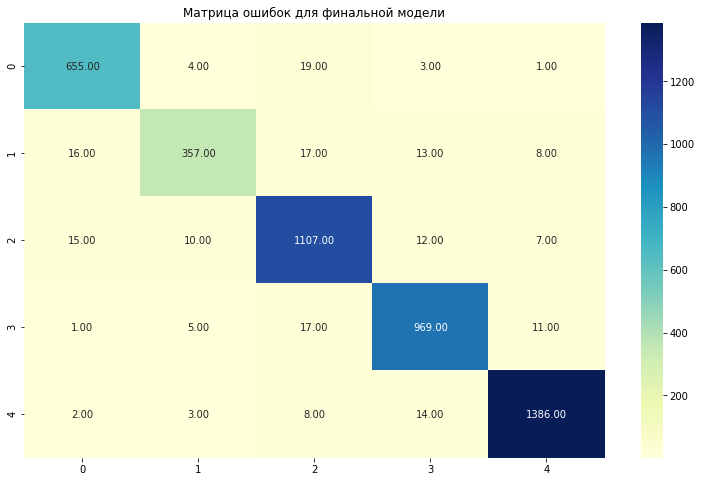

In [132]:
create_confusion_matrix(best_model, 
                        y_train_val, 
                        X_train_val, 
                        True,
                        'Матрица ошибок для финальной модели',
                        cv
                       )

Матрица ошибок говорит о том, что в целом модель работает правильно - темные цвета преобладают на главной диагонали матрицы, качество предсказаний зависит от численности класса - лучше всего модель предсказывает большие классы, например, второй и четвертый, хуже всего малочисленные - первый и нулевой классы.

Получим значения метрик лучшей модели на тестовой выборке.

In [133]:
f1_result = f1_score(y_test, best_model.predict(X_test), average='macro')
precision_result = precision_score(y_test, best_model.predict(X_test), average='macro')
recall_result = recall_score(y_test, best_model.predict(X_test), average='macro')
print(f'''f1_macro = {round(f1_result, 3)}
precision_macro = {round(precision_result, 3)}
recall_macro = {round(recall_result, 3)}''')

f1_macro = 0.897
precision_macro = 0.898
recall_macro = 0.897


Таким образом, полученная модель удовлетворяет требованиям проекта и ее можно рекомендовать к внедрению, так как значение метрики `F1_macro` на тестовой выборке при кросс-валидации и на тестовой выборке более 0,75 - около 0,9. Значения метрик примерно совпадают на тренировочных данных и на тесте, что говорит о том, что модель не переобучилась.

Метрики `precision` и `recall` говорят о том, что:
- в среднем в 89,7% случаев модель не ошибается, присваивая объект к определенному классу;
- в среднем в 89,5% случаев модель может находить объекты, принадлежащие определенному классу.

#### Вывод по 6.2
Финальная модель была сохранена в отдельную переменную, для нее была построена матрица ошибок и посчитаны метрики на тестовой выборке:
- `f1_macro` = 0.896;
- `precision_macro` = 0.897;
- `recall_macro` = 0.895.

Модель можно рекомендовать к внедрению, так как значение ее основной метрики `f1_macro` больше 0.75.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

### Вывод по разделу 6
В результате выполнения раздела 6 были созданы сетки гиперпараметров для их перебора у моделей, которые показали лучшие результаты на момент тестирования базовых моделей - OVR и OVO с базовой моделью SVC с rbf-ядром. По итогам подбора лучшей моделью оказалась One-vs-Rest и базовой моделью SVC с rbf-ядром, значение метрики F1_macro которой равно 0.908 и значения гиперпараметров:
- `C` = 1;
- `gamma` - scale. 

Финальная модель была сохранена в отдельную переменную, для нее была построена матрица ошибок и посчитаны метрики на тестовой выборке:
- `f1_macro` = 0.896;
- `precision_macro` = 0.897;
- `recall_macro` = 0.895.

Модель можно рекомендовать к внедрению, так как значение ее основной метрики `f1_macro` больше 0.75.


<a class="anchor" id="7-bullet"></a>
## 7. Подготовка артефактов модели для внедрения

Сохраним итоговую модель с пайплайном и функцию для первичной обработки датафреймов с помощью joblib.

In [134]:
joblib.dump(best_model, 'age_prediction.joblib')
joblib.dump(processing_initial_tables, 'processing_initial_tables.joblib')

['processing_initial_tables.joblib']

Проверим сохранения.

Проверка сохранения функции для первичной обработки датафреймов.

In [135]:
loaded_function = joblib.load('processing_initial_tables.joblib')

In [136]:
df_after_joblib = loaded_function(df_users_start,
                     df_visits_start,
                     df_ads_activity_start,
                     df_surf_depth_start,
                     df_primary_device_start,
                     df_cloud_usage_start)

---> Обработка таблицы df_users
Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 87
Кол-во дубликатов после их удаления: 0

Проверим количество пропусков в данных:
user_id         0
age_category    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца age_category на выбросы. Уникальные значения:
[4 2 0 1 3]

---> Обработка таблицы df_ads_activity
Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 233
Кол-во дубликатов после их удаления: 0

Проверим количество пропусков в данных:
user_id         0
ads_activity    0
dtype: int64 

Проверка на уникальность каждого идентификатора пользователя. Результат:
True 

Проверка столбца ads_activity на выбросы. Уникальные значения:
['очень часто' 'редко' 'очень редко' 'умеренно' 'часто']

---> Обработка таблицы df_surf_depth
Проверим кол-во дубликатов и удалим их при необходимости:
Кол-во дубликатов: 0
Проверим количество пропусков в д

Размер датасета совпадает с ожидаемым, проверим его первые строки.

In [137]:
df_after_joblib.head(3)

,user_id,age_category,mean_sessions_count,website_category_1,website_category_2,website_category_3,website_category_4,website_category_5,website_category_6,website_category_7,website_category_8,website_category_9,website_category_10,website_category_11,website_category_12,website_category_13,website_category_14,website_category_15,website_category_16,website_category_17,website_category_18,website_category_19,website_category_20,most_popular_daytime,count_morning,count_day,count_evening,count_night,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,13.357143,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,0.000000,0.048128,0.101604,0.026738,0.074866,0.016043,0.032086,0.037433,0.053476,0.042781,0.058824,0.069519,0.074866,0.042781,день,0.229947,0.358289,0.336898,0.074866,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,10.071429,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,0.042553,0.070922,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461,вечер,0.177305,0.340426,0.390071,0.092199,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,7.142857,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,0.000000,0.010000,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000,вечер,0.200000,0.290000,0.380000,0.130000,умеренно,средне,смартфон,False


Первый строки так же выглядят корректно, значит загрузка артефактов произошла правильно.

Проверим сохранения пайплайна и модели, предварительно разделив данные на выборки.

In [138]:
X_after_joblib, y_after_joblib = df_after_joblib.drop('age_category', axis=1), df_after_joblib['age_category']
X_tv_after_joblib, X_test_after_joblib, y_tv_after_joblib, y_test_after_joblib = train_test_split(X_after_joblib, 
                                                                                                                y_after_joblib, 
                                                                                                                test_size=TEST_SIZE, 
                                                                                                                shuffle=True, 
                                                                                                                random_state=RANDOM_SEED,
                                                                                                                stratify=y_after_joblib)

Загрузим пайплайн и проверим значения метрик на тестовых выборках, полученных из датафрейма, который вернула функция `processing_initial_tables`.

In [139]:
loaded_pipeline = joblib.load('age_prediction.joblib')

In [140]:
f1_result2 = f1_score(y_test_after_joblib, loaded_pipeline.predict(X_test_after_joblib), average='macro')
precision_result2 = precision_score(y_test_after_joblib, loaded_pipeline.predict(X_test_after_joblib), average='macro')
recall_result2 = recall_score(y_test_after_joblib, loaded_pipeline.predict(X_test_after_joblib), average='macro')
print(f'''f1_macro = {round(f1_result2, 3)}
precision_macro = {round(precision_result2, 3)}
recall_macro = {round(recall_result2, 3)}''')

f1_macro = 0.897
precision_macro = 0.898
recall_macro = 0.897


Загрузка произошла успешно, значения метрик примерно совпали.

### Вывод по разделу 7
Пайплайн и функция для объединения датафреймов были успешно сохранены как артефакты, была проведена загрузка сохраненных артефактов, посчитаны метрики на выгрузках, которые оказались корректными. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="8-bullet"></a>
## 8. Выводы о результатах работы

Для выполнения проекта было дано 6 датафреймов, содержащих в себе информацию о категории возраста пользователей, логах посещения ими сайтов, показателями частотности взаимодействия пользователей с рекламой, информацией о глубине переходов пользователей по сайтам во время одной сессии, их типах устройств и наличии обращений к облачным ресурсам. 

Было проведено исследование целевой переменной из первого датафрейма, выявлено наличие дисбаланса, где наиболее распространенной возрастной категорией IT-компании являются взрослые люди в возрасте 56+ лет, наименее распространенной категорией - пользователи в возрасте 18-25 лет.

Каждый датафрейм был предобработан по отдельности. Были рассмотрены такие аспекты:
- проверено кол-во дубликатов и при необходимости проведено их удаление;
- проверено количество пропусков;
- проведение проверка уникальности идентификаторов пользователей;
- проведена проверка на явные выбросы.

В результате:
- на основе датафрейма df_visits были составлены новые признаки с наиболее активным временем суток у пользователей, долей интернет-активности для каждого времени суток, долевым распределением интересов пользователей по разным категориям сайтов, средним количеством сессий пользователей в день; 
- в некоторых признаках были найдены дубликаты, которые были удалены. 
- выбросов и пропусков найдена в данных не было.

Была написана функция для объединения всех датафреймов в один, после применения которой мы получили основной датафрейм для выполнения проекта.
 
В ходе работы с основным датафреймом были проделаны следующие этапы:
- дано описание базовой информации о новом датафрейме;
- проведен анализ признаков;
- проанализированы пропуски;
- проанализированы категориальные признаки;
- проанализированы распределения и графики на наличия выбросов;
- рассмотрены корреляции.

Далее данные были поделены на выборки для train/val и test, создано 3 пайплайна, которые были обхединены в один трансформер. Пайплайны:
- 2 для обработки категориальных данных, чтобы была возможность применить разные виды кодирования;
- 1 для числовых данных - с обработкой пропусков и масштабированием с помощью StandardScaler.

Были обучены 8 моделей, получены для них значения метрик `F1-мера`, `precision` и `recall`, построены матрицы ошибок и тепловые карты для их визуализации. Лучшими моделями по результатам обучений по метрике `F1-мера` оказались One-vs-Rest с SVC, у которой ядро RBF и One-vs-One с SVC, у которой ядро RBF, для них значение метрики равно 0.9.

Для отбора признаков были применены фильтрационные методы (метрика MI и построение phik-матрицы) и методы-обертки (с прямым проходом и RFE). В финальный набор признаков вошли:
- все категории сайтов
- `count_morning`;  
- `count_night`;
- `most_popular_daytime`;
- `count_evening`;
- `surf_depth`;
- `primary_device`.

Был использован GridSearchCV для подбора гиперпараметров для моделей. В качестве основных моделей, для которых осуществлялся подбор гиперпараметров, были взяты модели, показавшие наилучшие метрики на момент работы с базовыми моделями:
- One-vs-Rest с базовой моделью SVC с ядром RBF;
- One-vs-One с базовой моделью SVC с ядром RBF.

Для подбора были созданы сетки гиперпараметров для их перебора. По итогам подбора лучшей моделью оказалась One-vs-Rest и базовой моделью SVC с rbf-ядром, значение метрики `F1_macro` которой равно 0.908 и значения гиперпараметров:
- `C` = 1;
- `gamma` - scale.  

Финальная модель, оказавшаяся лучшей после подбора гиперпараметров (One-vs-Rest с базовой моделью SVC с rbf-ядром), была сохранена в отдельную переменную, для нее была построена матрица ошибок и посчитаны метрики на тестовой выборке:
- `f1_macro` = 0.896;
- `precision_macro` = 0.897;
- `recall_macro` = 0.895.

Модель можно рекомендовать к внедрению, так как значение ее основной метрики `f1_macro` больше 0,75 как на тренировочной выборке при кросс-валидации, так и на тестовой выборке.

После завершения основной части проекта пайплайн и функция для объединения датафреймов были успешно сохранены как артефакты, была проведена загрузка сохраненных артефактов, посчитаны метрики на выгрузках. Результаты оказались корректными.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>